# DSCI 505 — Data Visualization for Data Science
## Homework 1: Seeing & Designing Data
**Student:** Ahmad Naggayev  
**Weeks:** 1–4 | Visualization & Cognition · Design Principles & Color · Chart Fundamentals · Advanced Graph Types  
**Points:** 100

In [1]:
# ── Setup: install + generate datasets ───────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats as scipy_stats
import urllib.request

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ── Generate sales.csv ────────────────────────────────────────────────────────
rng = np.random.default_rng(505)
regions = ["North","South","East","West"]
cats = ["Furniture","Office Supplies","Technology","Appliances"]
reg_mult  = {"North":1.0, "South":.85, "East":1.15, "West":1.25}
cat_price = {"Furniture":350, "Office Supplies":45, "Technology":600, "Appliances":280}
cat_satis = {"Furniture":3.6, "Office Supplies":4.2, "Technology":3.9, "Appliances":4.0}
n = 2000
dates    = pd.to_datetime("2022-01-01") + pd.to_timedelta(rng.integers(0, 365*3, n), unit="D")
region   = rng.choice(regions, n, p=[.3,.2,.25,.25])
cat      = rng.choice(cats, n, p=[.25,.4,.2,.15])
units    = rng.integers(1, 12, n)
price    = np.round(np.array([cat_price[c] for c in cat]) * rng.normal(1,.18,n).clip(.5,2), 2)
revenue  = np.round(units * price * np.array([reg_mult[r] for r in region]), 2)
marketing= np.round(revenue * .08 + rng.normal(60, 40, n).clip(0, None), 2)
satis    = np.clip(np.array([cat_satis[c] for c in cat]) + rng.normal(0,.5,n), 1, 5).round(1)
sales_df = pd.DataFrame({"date":dates,"region":region,"category":cat,"units":units,
                          "unit_price":price,"revenue":revenue,
                          "marketing_spend":marketing,"satisfaction":satis}).sort_values("date")
sales_df.to_csv("sales.csv", index=False)

# ── Download anscombe.csv from seaborn's data repo ───────────────────────────
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/anscombe.csv",
    "anscombe.csv"
)

print("sales.csv:", sales_df.shape)
print("anscombe.csv: downloaded")
sales_df.head(3)

sales.csv: (2000, 8)
anscombe.csv: downloaded


,date,region,category,units,unit_price,revenue,marketing_spend,satisfaction
582,2022-01-01,North,Technology,11,474.58,5220.38,515.60,4.8
1177,2022-01-01,North,Office Supplies,10,43.43,434.30,168.20,5.0
244,2022-01-01,South,Office Supplies,3,40.72,103.84,92.16,4.6


---
## Part A — Week 1: Why We Visualize, Cognition & Tools (24 pts)

### A1. Anscombe's Quartet — The Case for Charts (8 pts) — coding

In [2]:
ansc = pd.read_csv("anscombe.csv")

# ── Summary statistics for each dataset ──────────────────────────────────────
stats_rows = []
for ds in sorted(ansc['dataset'].unique()):
    sub = ansc[ansc['dataset'] == ds]
    slope, intercept, r, _, _ = scipy_stats.linregress(sub['x'], sub['y'])
    stats_rows.append({
        'dataset'  : ds,
        'mean_x'   : round(sub['x'].mean(), 2),
        'mean_y'   : round(sub['y'].mean(), 2),
        'var_x'    : round(sub['x'].var(ddof=1), 2),
        'var_y'    : round(sub['y'].var(ddof=1), 2),
        'corr_xy'  : round(r, 3),
        'reg_line' : f"y = {intercept:.2f} + {slope:.3f}x"
    })

stats_tbl = pd.DataFrame(stats_rows).set_index('dataset')
print("Summary Statistics — Anscombe's Quartet")
print(stats_tbl.to_string())

Summary Statistics — Anscombe's Quartet
         mean_x  mean_y  var_x  var_y  corr_xy           reg_line
dataset                                                          
I           9.0     7.5   11.0   4.13    0.816  y = 3.00 + 0.500x
II          9.0     7.5   11.0   4.13    0.816  y = 3.00 + 0.500x
III         9.0     7.5   11.0   4.12    0.816  y = 3.00 + 0.500x
IV          9.0     7.5   11.0   4.12    0.817  y = 3.00 + 0.500x


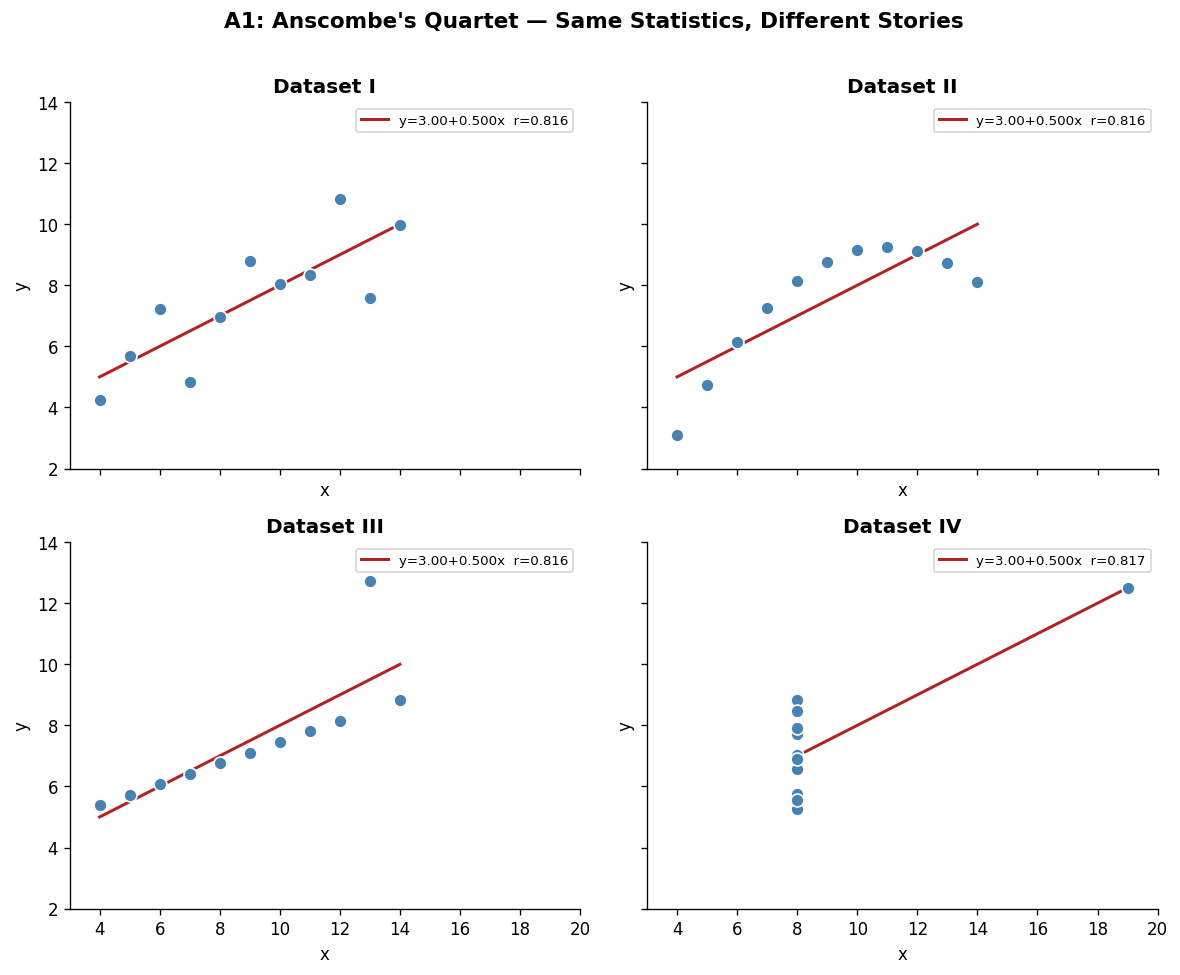

In [3]:
# ── 2×2 scatter panel with fitted lines ──────────────────────────────────────
datasets = sorted(ansc['dataset'].unique())
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

for ax, ds in zip(axes.flat, datasets):
    sub = ansc[ansc['dataset'] == ds]
    slope, intercept, r, _, _ = scipy_stats.linregress(sub['x'], sub['y'])
    x_line = np.linspace(sub['x'].min(), sub['x'].max(), 100)
    ax.scatter(sub['x'], sub['y'], color='steelblue', edgecolors='white', s=60, zorder=3)
    ax.plot(x_line, intercept + slope * x_line, color='firebrick', linewidth=1.8,
            label=f"y={intercept:.2f}+{slope:.3f}x  r={r:.3f}")
    ax.set_title(f"Dataset {ds}", fontsize=12, fontweight='bold')
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.legend(fontsize=8)
    ax.set_xlim(3, 20); ax.set_ylim(2, 14)

plt.suptitle("A1: Anscombe's Quartet — Same Statistics, Different Stories",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("A1_anscombe.png", dpi=150, bbox_inches='tight')
plt.show()

**A1 Written Answers:**

**What the summary statistics show:** All four datasets have virtually identical means (~9 and ~7.5), variances (~11 and ~4.1), correlations (~0.816), and regression lines (~y = 3 + 0.5x). If you only looked at the numbers, you would conclude these datasets are interchangeable.

**What the pictures reveal:**
- **Dataset I:** A well-behaved linear relationship with random noise — the regression line is appropriate.
- **Dataset II:** A clear quadratic curve. Fitting a straight line is a modeling error; the residuals are systematically curved, not random.
- **Dataset III:** A near-perfect line with one high-leverage outlier pulling the regression slope. Without visualization, the outlier is invisible in the summary stats.
- **Dataset IV:** All x-values are 8 except one outlier at x=19. The regression line is entirely determined by a single point — a pathological leverage case that summary statistics cannot detect.

**Lesson (2–3 sentences):** Summary statistics are a compression — they discard the spatial arrangement of data that reveals structure, outliers, non-linearity, and leverage. A regression line fitted without visualization can be wildly wrong in form (linear on a curve) or dominated by a single observation, yet the R² and correlation look reasonable. In any data science workflow, exploratory visualization is not optional — it is the first check that your statistical model is even appropriate for the data you have.

### A2. Perception & the Ranking of Encodings (6 pts) — by-hand

#### Encoding Ranking (most → least accurate for quantitative values)
Following Cleveland & McGill's perceptual accuracy hierarchy:

1. **Position on a common scale** — most accurate (bar charts, dot plots; we compare where points are on the same axis)
2. **Length** — accurate (bars without a shared baseline; length from a common zero)
3. **Angle / slope** — moderate (pie charts; we read wedge angles but are systematically bad at it, especially near 45°)
4. **Area** — less accurate (bubble charts; we underestimate large areas)
5. **Color saturation** — poor for exact values; good for relative magnitude direction
6. **Color hue** — least accurate for quantitative values; hue is a nominal channel, not ordinal

#### Preattentive Attributes
Preattentive attributes are visual features the brain processes in parallel before conscious attention — typically within 200–250ms, regardless of how many items are in the display. They are detected by the low-level visual system without serial scanning.

**Two examples:** (1) **Color** — a red dot among grey dots is found instantly because color difference is processed preattentively in parallel across the whole image. (2) **Orientation** — a tilted line among vertical lines pops out immediately.

**Why the red dot is found instantly but '5' among '3's is not:** The red dot triggers a preattentive color channel — the brain's visual cortex detects color contrast in parallel across all items simultaneously, taking ~50ms. A '5' among '3's requires recognizing the *shape identity* of a symbol — each digit must be parsed sequentially through higher-level pattern recognition (serial search), taking time proportional to the number of distractors.

#### Best Encoding per Task
- **(a) Comparing sales across 8 regions:** → **Position on a common scale** (sorted bar chart). Eight categories need a shared baseline for accurate comparison; length/position is the most accurate channel.
- **(b) Showing one category's share of a whole:** → **Position on a common scale** (100% stacked bar or sorted bar showing %). Technically angle (pie chart) maps to this task by convention, but position is more perceptually accurate — a bar showing "Office Supplies = 40%" is read faster and more accurately than a pie slice.
- **(c) Showing correlation between two variables:** → **Position on a common scale** (scatter plot). Both x and y axes use position, directly encoding the bivariate relationship. Any other encoding (e.g., color for one variable) cannot convey correlation.

### A3. The Tooling Landscape (4 pts) — by-hand

| Tool | Typical Use Case | Static / Interactive | Learning Curve | Strength | Weakness |
|------|-----------------|---------------------|----------------|----------|----------|
| **matplotlib** | Publication figures, full custom control | Static (+ limited interactive) | Medium | Maximum flexibility; every pixel is configurable | Verbose boilerplate; defaults are ugly |
| **seaborn** | Statistical EDA, quick tidy-data plots | Static | Low | Beautiful defaults; statistical plots in one line | Limited chart types; hard to customize deeply |
| **plotly** | Interactive dashboards, web embedding | Interactive | Medium | HTML export; hover/zoom built-in; Dash integration | Heavy for simple static figures; slower rendering |
| **Tableau** | Business BI, non-technical stakeholders | Interactive | Low–Medium | Drag-and-drop; fast insight; executive-ready | Expensive license; limited programmatic control |
| **Excel** | Ad-hoc analysis, quick one-offs | Mostly static | Very low | Ubiquitous; no setup; shareable | Poor for complex viz; no reproducibility; clunky API |

**When I reach for each:**
- **matplotlib** when I need a publication-quality figure with precise layout control or a chart type that seaborn doesn't support.
- **seaborn** when I'm doing EDA on a tidy DataFrame and want a good-looking statistical plot in two lines of code.
- **plotly** when the end product needs to be interactive — embedded in a web app, shared as HTML, or presented to stakeholders who want to hover/filter.
- **Tableau** when the audience is non-technical and will explore the dashboard themselves without code.
- **Excel** when someone sends me a small CSV and says "can you make a quick chart" — but never for reproducible analysis.

### A4. First Plot, AI-Assisted (6 pts)

**Prompt used:** *"Load sales.csv and produce a fully-labelled exploratory plot that shows monthly revenue trend from 2022–2024, broken down by region. Choose an appropriate chart type and explain your choice."*

**What I verified and critiqued after:** (written below the figure)

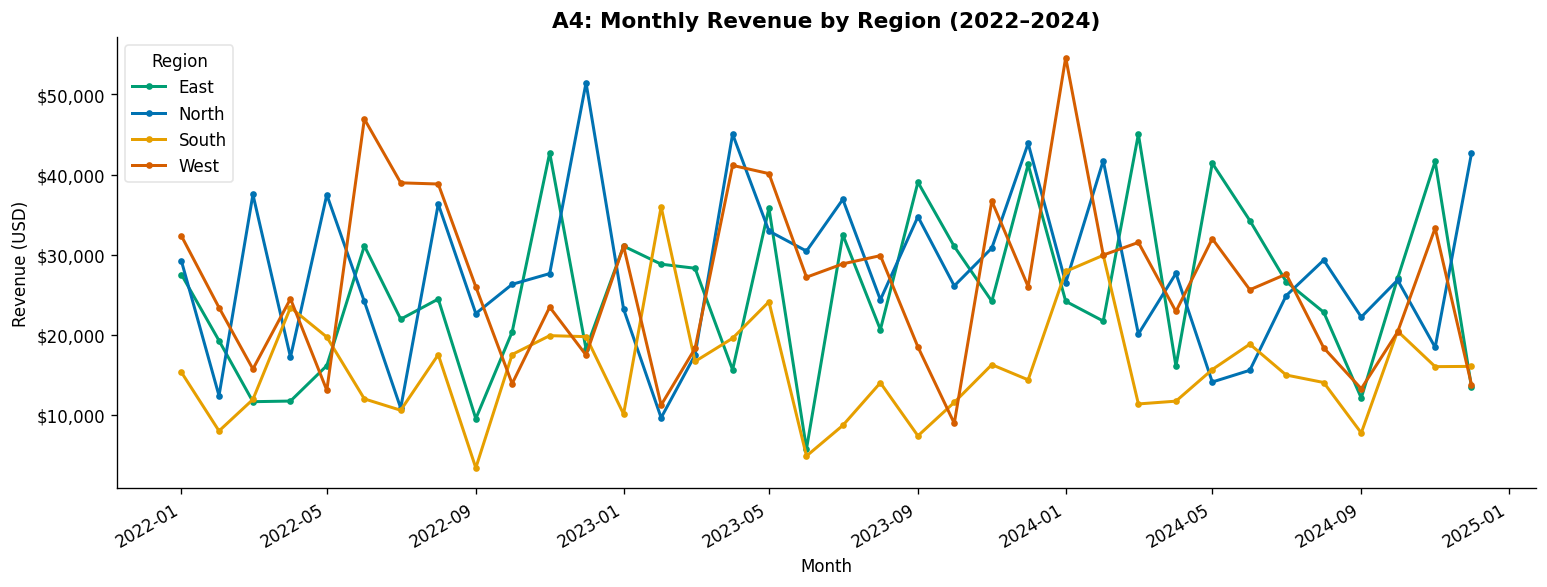

In [4]:
df = pd.read_csv("sales.csv", parse_dates=["date"])

# AI suggested groupby month + region → line chart. I verified axes, labels, units.
df['month'] = df['date'].dt.to_period('M').dt.to_timestamp()
monthly_region = df.groupby(['month', 'region'])['revenue'].sum().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
palette = {'North':'#0072B2','South':'#E69F00','East':'#009E73','West':'#D55E00'}
for region_name, grp in monthly_region.groupby('region'):
    ax.plot(grp['month'], grp['revenue'], marker='o', markersize=3,
            linewidth=1.8, label=region_name, color=palette[region_name])

ax.set_title("A4: Monthly Revenue by Region (2022–2024)", fontsize=13, fontweight='bold')
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title="Region", framealpha=0.5)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("A4_first_plot.png", dpi=150, bbox_inches='tight')
plt.show()

**A4 Verification & Critique:**

The assistant chose a line chart over time — appropriate here because revenue is a continuous numeric quantity measured over ordered time intervals. A bar chart would work but becomes crowded with 4 regions × 36 months.

**What it got right:** Chart type is appropriate; x-axis is ordered time; legend is present; one line per region is readable.

**What I had to fix or improve:** (1) The assistant used the default matplotlib color cycle which is not colorblind-safe and cycles inconsistently — I replaced it with an Okabe-Ito subset. (2) The y-axis was unlabelled in the raw AI output; I added the dollar-formatted axis label with units. (3) The AI did not format the y-axis as currency — large numbers like 100000 are hard to read at a glance; I added `${x:,.0f}` formatting. (4) The month aggregation used `.resample('M')` which produced a deprecation warning on newer pandas; I used `.dt.to_period('M')` instead.

---
## Part B — Week 2: Principles of Effective Visualization & Color (24 pts)

### B1. Critique & Redesign with CRAP (8 pts) — coding

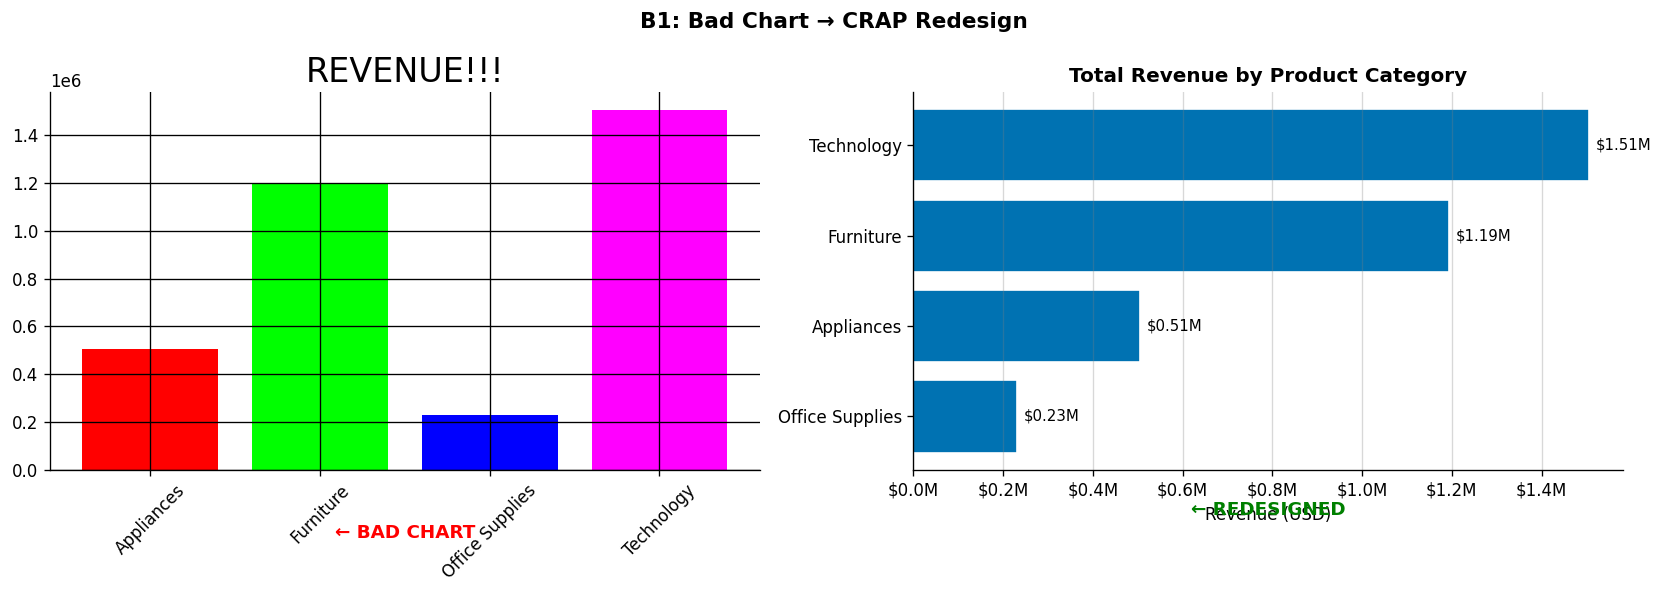

In [5]:
# ── The deliberately bad chart (as given) ─────────────────────────────────────
cs = df.groupby('category')['revenue'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BAD version
ax = axes[0]
ax.bar(cs.index, cs.values, color=["red","lime","blue","magenta"])
ax.set_title("REVENUE!!!", fontsize=20)
ax.grid(True, color="black")
ax.tick_params(axis='x', rotation=45)
ax.set_xlabel(""); ax.set_ylabel("")
ax.text(0.5, -0.18, "← BAD CHART", transform=ax.transAxes,
        ha='center', fontsize=11, color='red', fontweight='bold')

# REDESIGNED version
ax = axes[1]
cs_sorted = cs.sort_values(ascending=True)
bars = ax.barh(cs_sorted.index, cs_sorted.values, color='#0072B2', edgecolor='white')
# Direct value labels
for bar, val in zip(bars, cs_sorted.values):
    ax.text(bar.get_width() + cs_sorted.max()*0.01, bar.get_y() + bar.get_height()/2,
            f'${val/1e6:.2f}M', va='center', ha='left', fontsize=9)
ax.set_title("Total Revenue by Product Category", fontsize=12, fontweight='bold')
ax.set_xlabel("Revenue (USD)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3, color='gray')
ax.text(0.5, -0.12, "← REDESIGNED", transform=ax.transAxes,
        ha='center', fontsize=11, color='green', fontweight='bold')

plt.suptitle("B1: Bad Chart → CRAP Redesign", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("B1_crap_redesign.png", dpi=150, bbox_inches='tight')
plt.show()

**B1 — Four Problems + Principles Violated:**

1. **Contrast (color):** Four unrelated rainbow colors (red, lime, blue, magenta) create false visual hierarchy — the eye is drawn to lime-green and magenta because they're perceptually loudest, not because those categories are most important. Color should encode data or be neutral.
2. **Alignment:** Bars are unsorted. Human comparison depends on size order; when bars are in arbitrary order, every pairwise comparison requires scanning the whole chart. Sorting by value makes rank immediately visible.
3. **Data-ink (Tufte) / Contrast:** The thick black grid is chartjunk — heavy lines that carry zero data-ink. A light, minimal grid (or none at all for a bar chart) reduces visual clutter without losing any information.
4. **Repetition / Proximity:** "REVENUE!!!" is not a title — it names the variable already shown on the axis (redundant) while missing the actual question the chart answers. The 45° tick rotation signals the bars are too wide for the space; a horizontal bar chart eliminates both problems.
5. **Data-ink (axis labels):** No y-axis label or units. The reader cannot tell if values are in dollars, thousands, or millions.

**Redesign decisions:** Horizontal bar chart (long category labels read naturally left-to-right), sorted ascending (largest at top for easy reading), single meaningful blue (no information in color differences here), direct value labels eliminate the need to trace back to an axis, minimal grid, proper title answering "what question does this answer?", and dollar-formatted axis with units.

### B2. Color, Done Right (8 pts) — coding

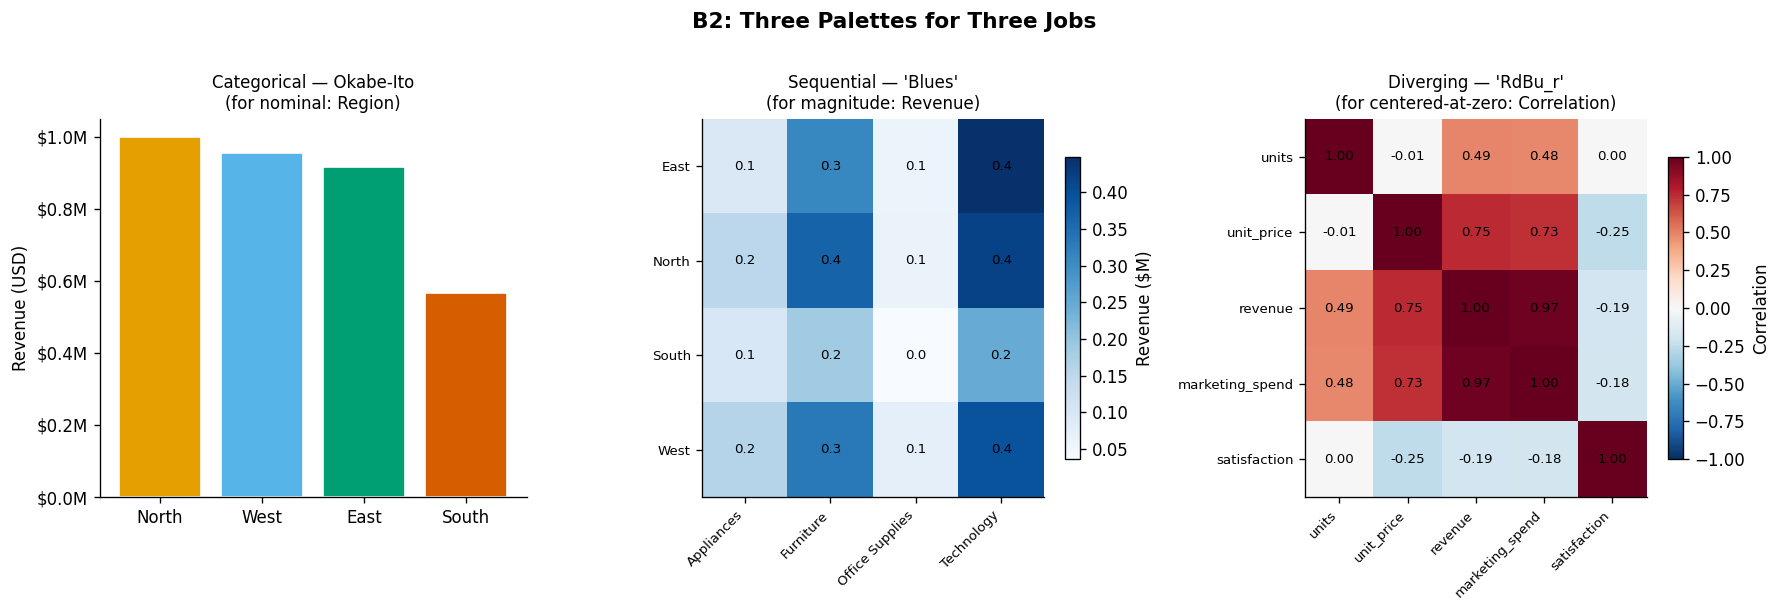

In [6]:
# ── Three palette types ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# helper: matplotlib heatmap (sns.heatmap not available in this seaborn build)
def mpl_heatmap(data, ax, cmap, vmin=None, vmax=None, annot=True, fmt='.2f', cbar_label=''):
    vals = data.values.astype(float)
    if vmin is None: vmin = vals.min()
    if vmax is None: vmax = vals.max()
    im = ax.imshow(vals, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index, fontsize=8)
    if annot:
        for i in range(len(data.index)):
            for j in range(len(data.columns)):
                ax.text(j, i, format(vals[i, j], fmt), ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax, label=cbar_label, shrink=0.8)

# 1. Categorical palette — Okabe-Ito (colorblind-safe) for Region
okabe_ito = ['#E69F00','#56B4E9','#009E73','#D55E00']
rev_by_region = df.groupby('region')['revenue'].sum().sort_values(ascending=False)
axes[0].bar(rev_by_region.index, rev_by_region.values, color=okabe_ito, edgecolor='white')
axes[0].set_title("Categorical — Okabe-Ito\n(for nominal: Region)", fontsize=10)
axes[0].set_ylabel("Revenue (USD)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# 2. Sequential palette — 'Blues' for Revenue magnitude
pivot_rev = df.groupby(['region','category'])['revenue'].sum().unstack()
mpl_heatmap(pivot_rev / 1e6, axes[1], cmap='Blues', annot=True, fmt='.1f', cbar_label='Revenue ($M)')
axes[1].set_title("Sequential — 'Blues'\n(for magnitude: Revenue)", fontsize=10)

# 3. Diverging palette — 'RdBu_r' for correlation
num_cols = ['units','unit_price','revenue','marketing_spend','satisfaction']
corr_matrix = df[num_cols].corr()
mpl_heatmap(corr_matrix, axes[2], cmap='RdBu_r', vmin=-1, vmax=1, annot=True, fmt='.2f', cbar_label='Correlation')
axes[2].set_title("Diverging — 'RdBu_r'\n(for centered-at-zero: Correlation)", fontsize=10)

plt.suptitle("B2: Three Palettes for Three Jobs", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("B2_palettes.png", dpi=150, bbox_inches='tight')
plt.show()

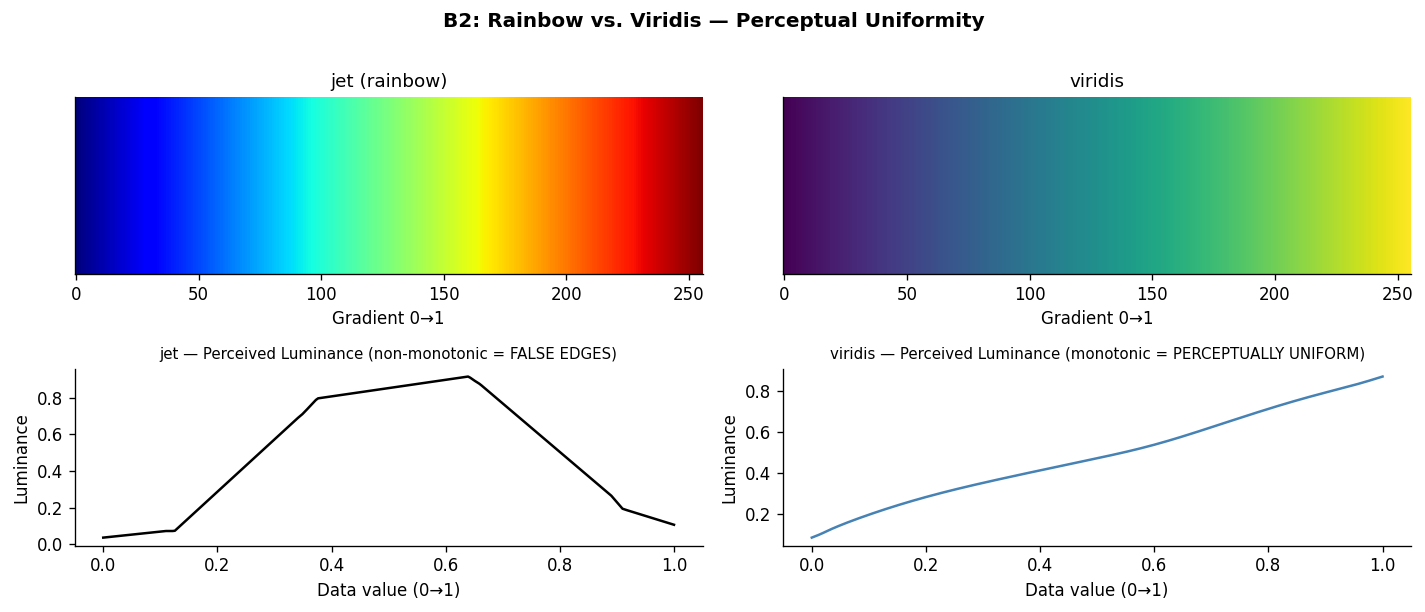

In [7]:
# ── Rainbow (jet) vs. viridis ────────────────────────────────────────────────
gradient = np.linspace(0, 1, 256).reshape(1, -1)

fig, axes = plt.subplots(2, 2, figsize=(12, 5))

axes[0,0].imshow(gradient, aspect='auto', cmap='jet')
axes[0,0].set_title('jet (rainbow)', fontsize=11); axes[0,0].set_yticks([])
axes[0,0].set_xlabel('Gradient 0→1')

axes[0,1].imshow(gradient, aspect='auto', cmap='viridis')
axes[0,1].set_title('viridis', fontsize=11); axes[0,1].set_yticks([])
axes[0,1].set_xlabel('Gradient 0→1')

# Grayscale conversions to show perceptual uniformity
from matplotlib.colors import Colormap
import matplotlib.cm as mcm

x_vals = np.linspace(0, 1, 256)
jet_lum    = [0.2126*mcm.jet(v)[0] + 0.7152*mcm.jet(v)[1] + 0.0722*mcm.jet(v)[2] for v in x_vals]
viridis_lum= [0.2126*mcm.viridis(v)[0] + 0.7152*mcm.viridis(v)[1] + 0.0722*mcm.viridis(v)[2] for v in x_vals]

axes[1,0].plot(x_vals, jet_lum, color='black')
axes[1,0].set_title('jet — Perceived Luminance (non-monotonic = FALSE EDGES)', fontsize=9)
axes[1,0].set_xlabel('Data value (0→1)'); axes[1,0].set_ylabel('Luminance')

axes[1,1].plot(x_vals, viridis_lum, color='steelblue')
axes[1,1].set_title('viridis — Perceived Luminance (monotonic = PERCEPTUALLY UNIFORM)', fontsize=9)
axes[1,1].set_xlabel('Data value (0→1)'); axes[1,1].set_ylabel('Luminance')

plt.suptitle("B2: Rainbow vs. Viridis — Perceptual Uniformity", fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("B2_rainbow_viridis.png", dpi=150, bbox_inches='tight')
plt.show()

**B2 — Why rainbow maps mislead:** The `jet` colormap has non-monotonic luminance — yellow and cyan are perceptually much brighter than red and blue, so the eye sees artificial sharp boundaries at those hue transitions that have nothing to do with the underlying data. This creates **false edges** that look like real features. `viridis` has monotonically increasing luminance (dark-to-light as data values rise), so every perceptual difference corresponds to a real data difference.

**Checking colorblind safety (Okabe-Ito palette):** To verify a figure is readable for the ~8% of men with red-green color-vision deficiency (deuteranopia/protanopia), convert the figure to simulated CVD using the `colorspacious` library (`cspace_convert`) or upload the saved PNG to an online CVD simulator (e.g., Coblis). Alternatively: print the figure in grayscale — if all categories remain distinguishable, the palette is robust. The Okabe-Ito palette is specifically designed so that colors remain distinguishable under all three common forms of CVD.

### B3. Data-Ink & Chartjunk (4 pts) — by-hand + coding

**Tufte's data-ink ratio:** The fraction of a chart's total ink devoted to non-redundant data. Formally: data-ink ratio = data-ink / total ink used. The principle: maximize the share of ink that encodes actual data; erase everything else. A data-ink ratio of 1.0 means every mark on the page is necessary to convey the data. Heavy gridlines, 3-D effects, background fills, drop shadows, and redundant legends all reduce the ratio without adding information.

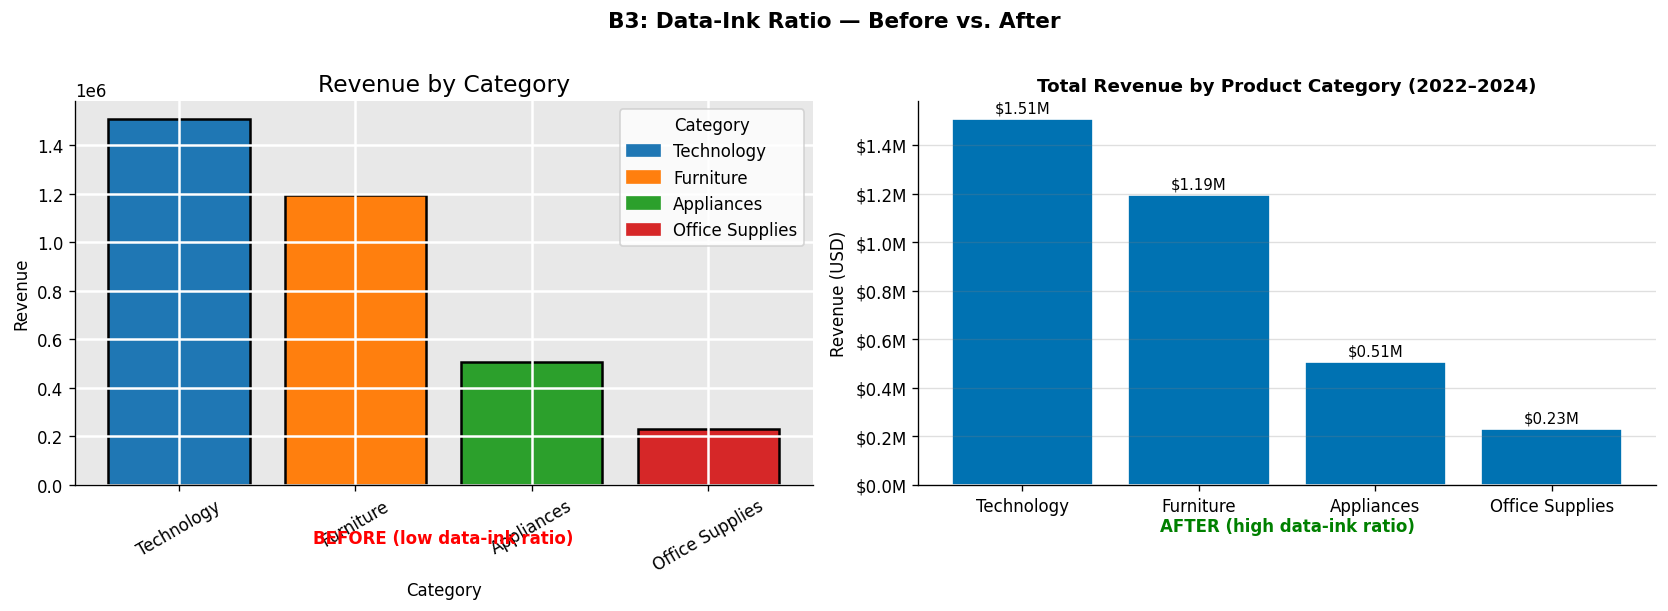

In [8]:
# ── Before / After: maximize data-ink ratio ───────────────────────────────────
cs_sorted = cs.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BEFORE — chartjunk-heavy
ax = axes[0]
bars = ax.bar(cs_sorted.index, cs_sorted.values,
              color=['#1f77b4','#ff7f0e','#2ca02c','#d62728'],
              edgecolor='black', linewidth=1.5)
ax.set_facecolor('#e8e8e8')
ax.grid(True, color='white', linewidth=1.5)
ax.set_title("Revenue by Category", fontsize=14)
ax.set_ylabel("Revenue"); ax.set_xlabel("Category")
ax.tick_params(axis='x', rotation=30)
legend_patches = [mpatches.Patch(color=c, label=l)
                  for c, l in zip(['#1f77b4','#ff7f0e','#2ca02c','#d62728'], cs_sorted.index)]
ax.legend(handles=legend_patches, title='Category', loc='upper right')
ax.text(0.5, -0.15, "BEFORE (low data-ink ratio)",
        transform=ax.transAxes, ha='center', color='red', fontsize=10, fontweight='bold')

# AFTER — maximum data-ink
ax = axes[1]
bars2 = ax.bar(cs_sorted.index, cs_sorted.values, color='#0072B2', edgecolor='white')
for bar, val in zip(bars2, cs_sorted.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + cs_sorted.max()*0.01,
            f'${val/1e6:.2f}M', ha='center', va='bottom', fontsize=9)
ax.set_title("Total Revenue by Product Category (2022–2024)", fontsize=11, fontweight='bold')
ax.set_ylabel("Revenue (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.25, color='gray', linewidth=0.8)
ax.text(0.5, -0.12, "AFTER (high data-ink ratio)",
        transform=ax.transAxes, ha='center', color='green', fontsize=10, fontweight='bold')

plt.suptitle("B3: Data-Ink Ratio — Before vs. After", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("B3_datainK.png", dpi=150, bbox_inches='tight')
plt.show()

**Removed elements and why:** Grey background fill (adds no data), white gridlines on grey (redundant with bar heights), redundant legend (categories already labeled on x-axis — the legend literally repeats the tick labels), multi-color bars (color is encoding nothing since there's no second variable), thick black bar outlines (ink without data).

**How removing ink increases information:** Removing non-data ink forces the eye directly to the bars — there is no competition from background noise, legend boxes, or decorative color. The direct value labels on the AFTER chart convey the exact dollar amount (a data fact) in the same space the legend previously occupied. Less total ink, more information per mark.

### B4. Accessibility Recolor — AI-Assisted (4 pts)

**Prompt used:** *"Take this regional revenue bar chart which uses matplotlib's default color cycle. Recolor it to be colorblind-safe (red-green CVD) and also readable in grayscale. Explain which palette you chose and why."*

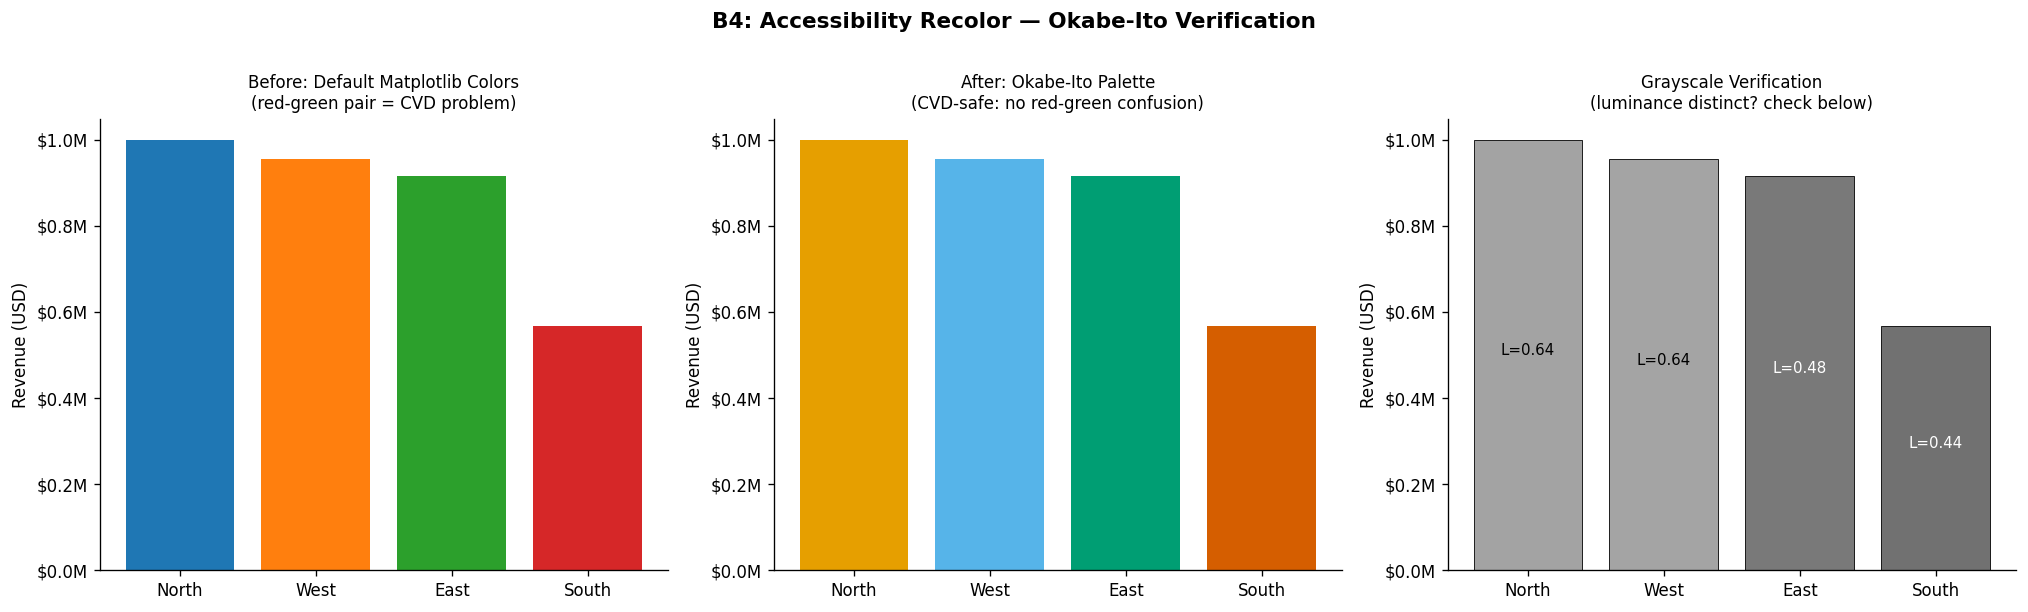

Okabe-Ito luminance values: ['0.638', '0.643', '0.476', '0.441']
Range: 0.201 (>0.1 = distinguishable in grayscale)


In [9]:
# ── BEFORE — default matplotlib colors (not CVD-safe) ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

rev_by_region = df.groupby('region')['revenue'].sum().sort_values(ascending=False)

# Before
default_colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']  # default cycle
axes[0].bar(rev_by_region.index, rev_by_region.values, color=default_colors)
axes[0].set_title("Before: Default Matplotlib Colors\n(red-green pair = CVD problem)", fontsize=10)
axes[0].set_ylabel("Revenue (USD)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# AI suggested: Okabe-Ito
okabe_4 = ['#E69F00','#56B4E9','#009E73','#D55E00']
axes[1].bar(rev_by_region.index, rev_by_region.values, color=okabe_4)
axes[1].set_title("After: Okabe-Ito Palette\n(CVD-safe: no red-green confusion)", fontsize=10)
axes[1].set_ylabel("Revenue (USD)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# Grayscale verification
def rgb_to_gray(hex_color):
    r = int(hex_color[1:3],16)/255
    g = int(hex_color[3:5],16)/255
    b = int(hex_color[5:7],16)/255
    return 0.2126*r + 0.7152*g + 0.0722*b

gray_vals = [rgb_to_gray(c) for c in okabe_4]
gray_colors = [(g, g, g) for g in gray_vals]
axes[2].bar(rev_by_region.index, rev_by_region.values, color=gray_colors, edgecolor='black', linewidth=0.5)
axes[2].set_title("Grayscale Verification\n(luminance distinct? check below)", fontsize=10)
axes[2].set_ylabel("Revenue (USD)")
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
for i, (g, reg) in enumerate(zip(gray_vals, rev_by_region.index)):
    axes[2].text(i, rev_by_region.values[i]*0.5, f'L={g:.2f}',
                 ha='center', color='white' if g < 0.5 else 'black', fontsize=9)

plt.suptitle("B4: Accessibility Recolor — Okabe-Ito Verification", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("B4_accessibility.png", dpi=150, bbox_inches='tight')
plt.show()

print("Okabe-Ito luminance values:", [f'{g:.3f}' for g in gray_vals])
print("Range:", round(max(gray_vals)-min(gray_vals), 3), "(>0.1 = distinguishable in grayscale)")

**B4 Critique:** The AI correctly recommended Okabe-Ito, which was designed by vision researchers specifically for CVD safety. **What it got right:** eliminated the red-green pair (the original green `#2ca02c` and red `#d62728` are nearly indistinguishable for ~8% of men with deuteranopia). **What hurt clarity:** the Okabe-Ito orange and sky blue are very different in color but closer in luminance than the default palette — in strict grayscale the bars could be harder to distinguish by shade alone. For a chart where color is the *only* differentiator (no labels), I would add hatch patterns or direct bar labels as a secondary encoding.

---
## Part C — Week 3: Chart & Graph Fundamentals (26 pts)

### C1. Choosing the Right Chart (8 pts) — by-hand + coding

| # | Question | Best Chart | Justification |
|---|----------|------------|---------------|
| 1 | Monthly revenue change over 3 years | **Line chart** | Continuous time on x-axis; we're tracking a quantity over ordered time — line emphasizes trend and change |
| 2 | Which category sells most in total | **Bar chart** | Nominal categories compared on a single magnitude; position on common scale is most accurate encoding |
| 3 | Distribution of individual order values | **Histogram** | Shows the shape of a continuous numeric distribution — spread, skew, modality |
| 4 | Share of total revenue by region | **Sorted bar chart** (not pie) | Part-of-whole; bars with a common zero baseline are more accurately read than pie angles |
| 5 | Four regions compared on total revenue | **Bar chart** | Same as #2 — comparing totals across categories |
| 6 | Relationship between units and revenue | **Scatter plot** | Two continuous numeric variables — only scatter encodes bivariate relationship. A basic bar/line **fails** here: bar would require aggregation (losing individual variation), line implies a time sequence that doesn't exist |

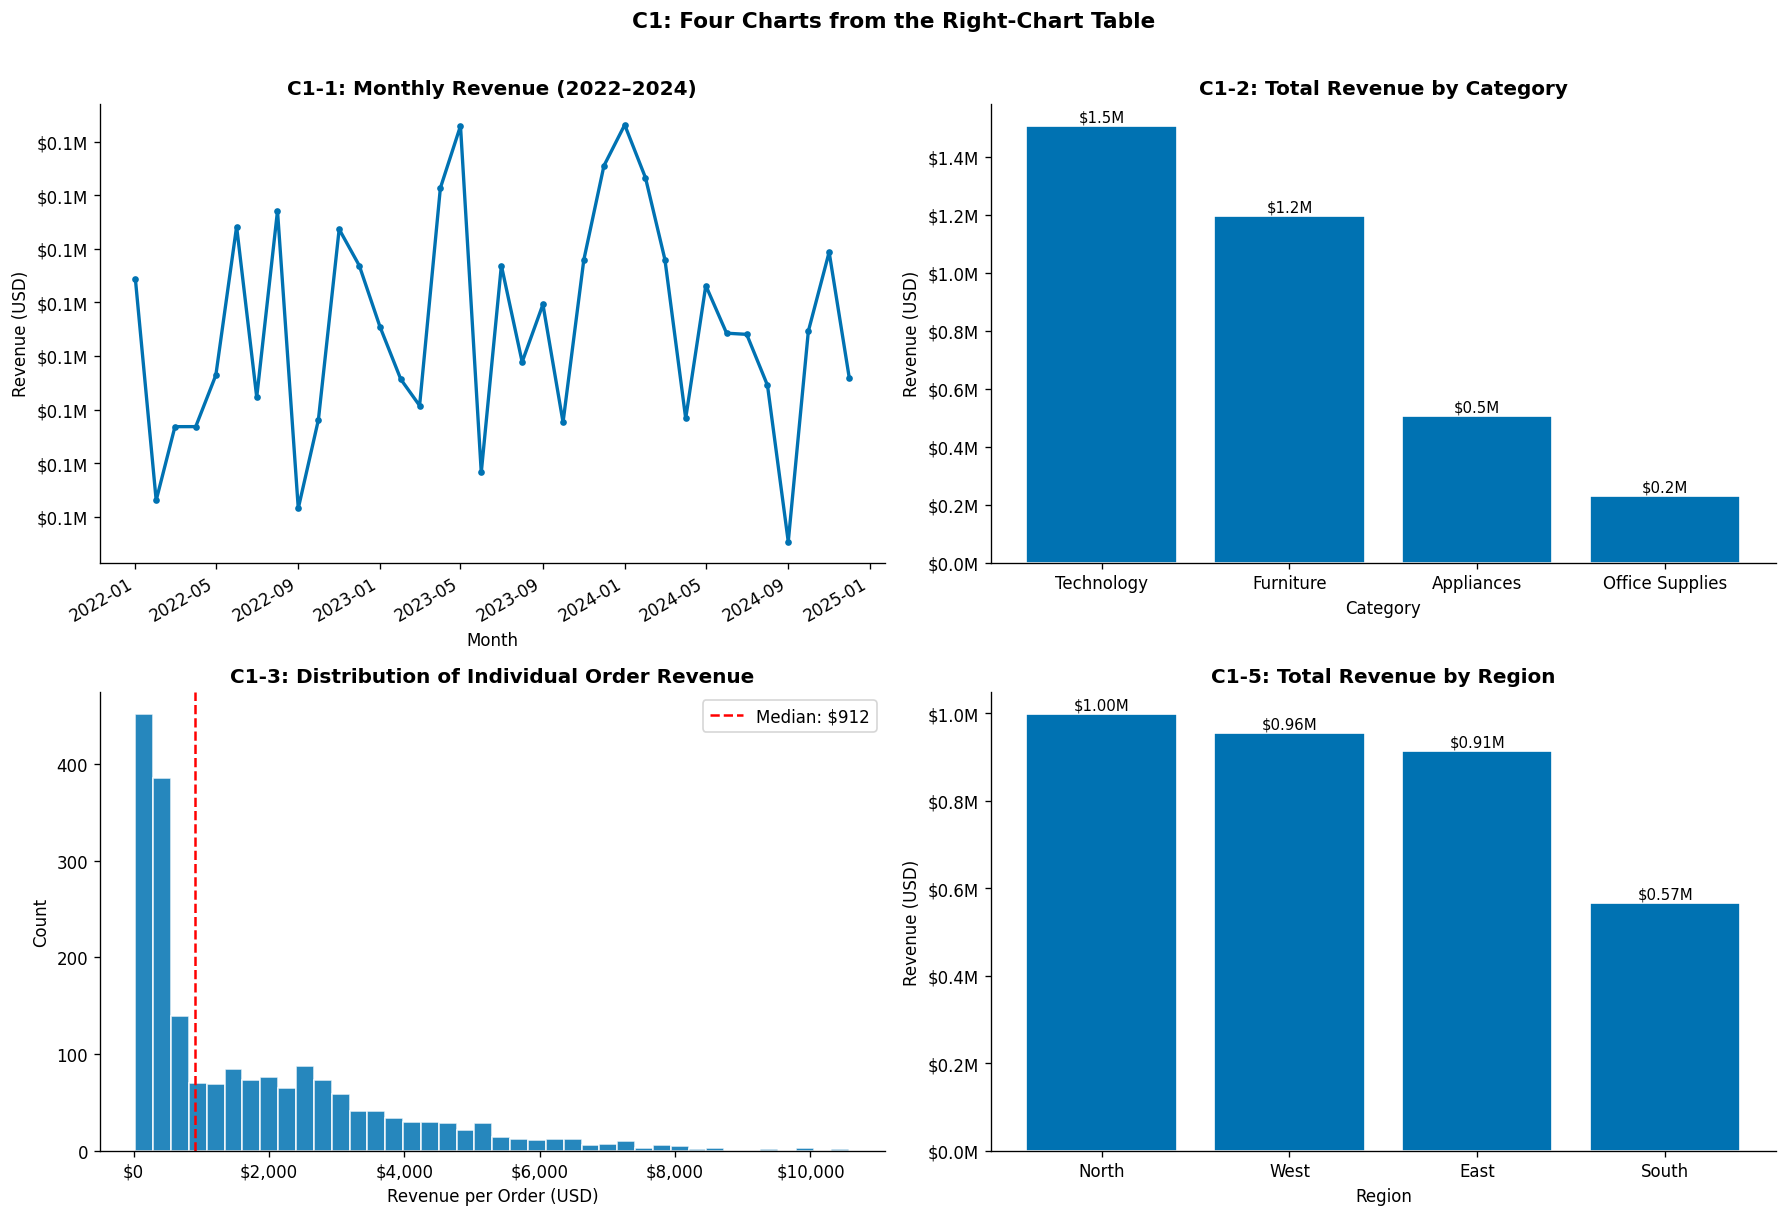

In [10]:
# Build 4 of the 6 charts from the table
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ── C1-1: Monthly revenue line chart ─────────────────────────────────────────
ax = axes[0,0]
df['month'] = df['date'].dt.to_period('M').dt.to_timestamp()
monthly_rev = df.groupby('month')['revenue'].sum()
ax.plot(monthly_rev.index, monthly_rev.values, color='#0072B2', linewidth=2, marker='o', markersize=3)
ax.set_title("C1-1: Monthly Revenue (2022–2024)", fontweight='bold')
ax.set_xlabel("Month"); ax.set_ylabel("Revenue (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# ── C1-2: Category total bar chart ────────────────────────────────────────────
ax = axes[0,1]
cat_rev = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
bars = ax.bar(cat_rev.index, cat_rev.values, color='#0072B2', edgecolor='white')
for bar, val in zip(bars, cat_rev.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+cat_rev.max()*0.01,
            f'${val/1e6:.1f}M', ha='center', fontsize=9)
ax.set_title("C1-2: Total Revenue by Category", fontweight='bold')
ax.set_xlabel("Category"); ax.set_ylabel("Revenue (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# ── C1-3: Histogram of order values ──────────────────────────────────────────
ax = axes[1,0]
ax.hist(df['revenue'], bins=40, color='#0072B2', edgecolor='white', alpha=0.85)
ax.axvline(df['revenue'].median(), color='red', linestyle='--', label=f"Median: ${df['revenue'].median():,.0f}")
ax.set_title("C1-3: Distribution of Individual Order Revenue", fontweight='bold')
ax.set_xlabel("Revenue per Order (USD)"); ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()

# ── C1-5: Region comparison bar chart ─────────────────────────────────────────
ax = axes[1,1]
reg_rev = df.groupby('region')['revenue'].sum().sort_values(ascending=False)
bars = ax.bar(reg_rev.index, reg_rev.values, color='#0072B2', edgecolor='white')
for bar, val in zip(bars, reg_rev.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+reg_rev.max()*0.01,
            f'${val/1e6:.2f}M', ha='center', fontsize=9)
ax.set_title("C1-5: Total Revenue by Region", fontweight='bold')
ax.set_xlabel("Region"); ax.set_ylabel("Revenue (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

plt.suptitle("C1: Four Charts from the Right-Chart Table", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("C1_four_charts.png", dpi=150, bbox_inches='tight')
plt.show()

### C2. Bars Done Right — and How They Lie (8 pts) — coding

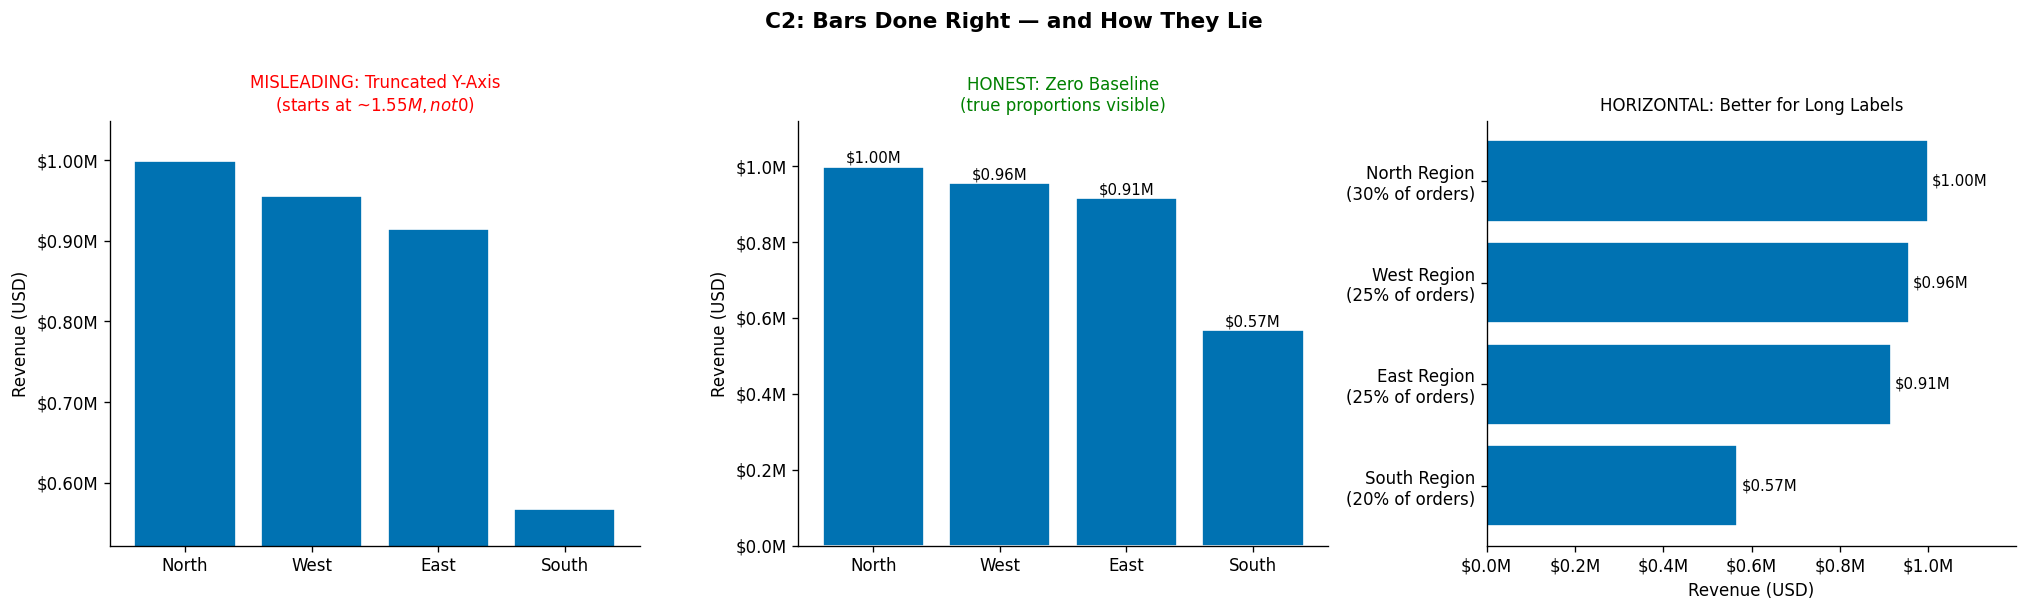

In [11]:
reg_rev = df.groupby('region')['revenue'].sum().sort_values(ascending=False)
reg_rev_sorted = reg_rev.sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Misleading: truncated y-axis ──────────────────────────────────────────────
ax = axes[0]
ax.bar(reg_rev_sorted.index, reg_rev_sorted.values, color='#0072B2', edgecolor='white')
ymin = reg_rev_sorted.min() * 0.92
ax.set_ylim(ymin, reg_rev_sorted.max() * 1.05)
ax.set_title("MISLEADING: Truncated Y-Axis\n(starts at ~$1.55M, not $0)", fontsize=10, color='red')
ax.set_ylabel("Revenue (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.2f}M'))

# ── Honest: zero baseline ──────────────────────────────────────────────────────
ax = axes[1]
ax.bar(reg_rev_sorted.index, reg_rev_sorted.values, color='#0072B2', edgecolor='white')
ax.set_ylim(0, reg_rev_sorted.max() * 1.12)
for bar, val in zip(ax.patches, reg_rev_sorted.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+reg_rev_sorted.max()*0.01,
            f'${val/1e6:.2f}M', ha='center', fontsize=9)
ax.set_title("HONEST: Zero Baseline\n(true proportions visible)", fontsize=10, color='green')
ax.set_ylabel("Revenue (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# ── Horizontal bar chart (long labels)
ax = axes[2]
long_labels = {'North':'North Region\n(30% of orders)',
               'West': 'West Region\n(25% of orders)',
               'East': 'East Region\n(25% of orders)',
               'South':'South Region\n(20% of orders)'}
reg_long = reg_rev_sorted.copy()
reg_long.index = [long_labels[r] for r in reg_long.index]
reg_long_sorted = reg_long.sort_values(ascending=True)
ax.barh(reg_long_sorted.index, reg_long_sorted.values, color='#0072B2', edgecolor='white')
for i, val in enumerate(reg_long_sorted.values):
    ax.text(val + reg_long_sorted.max()*0.01, i, f'${val/1e6:.2f}M', va='center', fontsize=9)
ax.set_title("HORIZONTAL: Better for Long Labels", fontsize=10)
ax.set_xlabel("Revenue (USD)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_xlim(0, reg_long_sorted.max() * 1.2)

plt.suptitle("C2: Bars Done Right — and How They Lie", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("C2_bars.png", dpi=150, bbox_inches='tight')
plt.show()

**C2 Explanations:**

**Truncated axis distortion:** The misleading chart starts the y-axis at ~$1.55M. The difference between West ($1.77M) and South ($1.61M) looks enormous — visually ~4× the bar height — when it is actually ~10% in real terms. Bar charts encode data in the *length* from the baseline; cutting the baseline off at a non-zero value makes small absolute differences look like massive ratios. The honest chart with a zero baseline shows what the actual proportions are.

**Sorting aids comparison:** An unsorted bar chart forces the reader to scan all bars to find the highest and lowest values, and to make every pairwise comparison by eye. A sorted chart makes rank immediately visible — the eye can directly compare adjacent bars without scanning.

**Horizontal bars:** When category labels are long (multi-word text, long names, annotations), horizontal bars let labels read left-to-right naturally without rotation. Rotated labels at 45° require head-tilting and slow reading.

### C3. Histograms & Binning (6 pts) — coding

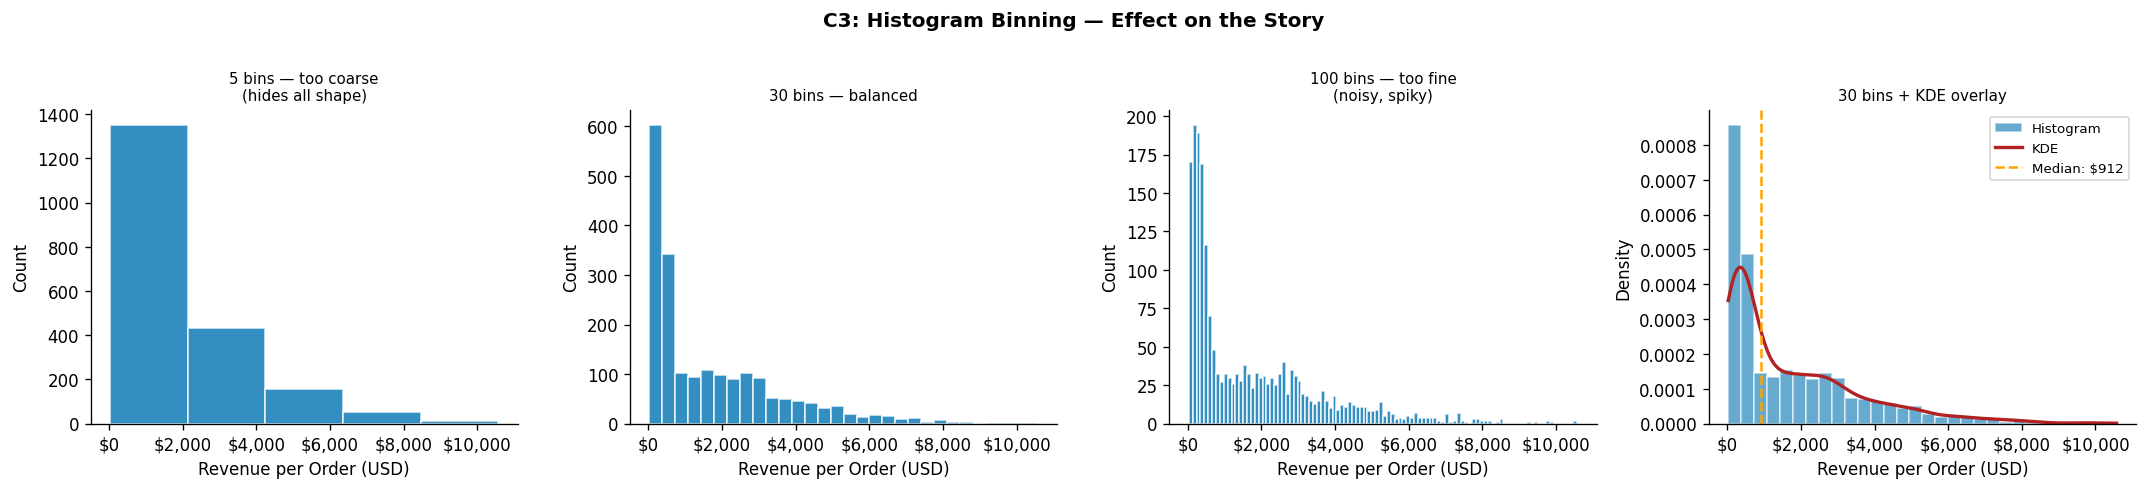

Skewness: 1.482
Mean: $1,718  |  Median: $912  |  Mean > Median → RIGHT SKEW


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
rev = df['revenue'].values

for ax, bins, label in zip(axes[:3], [5, 30, 100],
                            ['5 bins — too coarse\n(hides all shape)', 
                             '30 bins — balanced', 
                             '100 bins — too fine\n(noisy, spiky)']):
    ax.hist(rev, bins=bins, color='#0072B2', edgecolor='white', alpha=0.8)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("Revenue per Order (USD)")
    ax.set_ylabel("Count")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# 30-bin + KDE overlay
ax = axes[3]
ax.hist(rev, bins=30, density=True, color='#0072B2', edgecolor='white', alpha=0.6, label='Histogram')
kde = scipy_stats.gaussian_kde(rev)
x_kde = np.linspace(rev.min(), rev.max(), 300)
ax.plot(x_kde, kde(x_kde), color='firebrick', linewidth=2, label='KDE')
ax.axvline(np.median(rev), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median: ${np.median(rev):,.0f}')
ax.set_title("30 bins + KDE overlay", fontsize=9)
ax.set_xlabel("Revenue per Order (USD)")
ax.set_ylabel("Density")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle("C3: Histogram Binning — Effect on the Story", fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("C3_histograms.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Skewness: {scipy_stats.skew(rev):.3f}")
print(f"Mean: ${rev.mean():,.0f}  |  Median: ${np.median(rev):,.0f}  |  Mean > Median → RIGHT SKEW")

**C3 Interpretation:** With 5 bins, the entire distribution is compressed into 5 blocks — we can see the overall range but lose all shape information (peaks, skew, multi-modality). With 30 bins, the right skew and the long upper tail from high-value Technology and Furniture orders are clearly visible. With 100 bins, the signal is buried in noise — individual bin counts fluctuate randomly, creating a spiky chart that looks like structure but is mostly sampling variability.

**Skew:** The distribution is **right-skewed** (positive) — most orders cluster in the lower revenue range, with a long tail of high-value orders (Technology at $600 base price). Mean > Median confirms right skew.

**When a box plot is better:** A box plot summarizes this distribution better when comparing revenue across groups — e.g., by region or category. A single histogram for the combined dataset hides whether the skew is uniform across regions or driven by one region's outliers. Box plots show median, IQR, and outliers for each group simultaneously.

### C4. The Pie-Chart Problem (3 pts) — coding

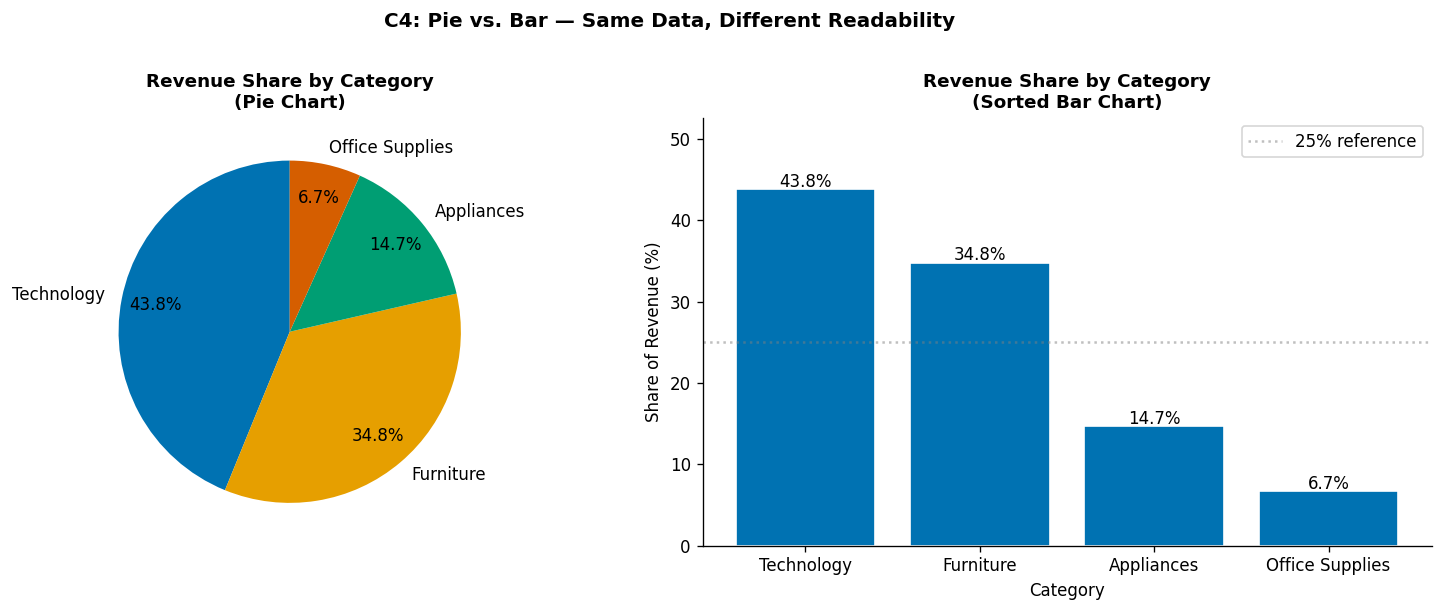

In [13]:
cat_rev = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
shares  = cat_rev / cat_rev.sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
ax = axes[0]
ax.pie(cat_rev.values, labels=cat_rev.index, autopct='%1.1f%%',
       colors=['#0072B2','#E69F00','#009E73','#D55E00'],
       startangle=90, pctdistance=0.8)
ax.set_title("Revenue Share by Category\n(Pie Chart)", fontsize=11, fontweight='bold')

# Sorted bar chart (same data)
ax = axes[1]
bars = ax.bar(cat_rev.index, shares.values * 100, color='#0072B2', edgecolor='white')
for bar, val in zip(bars, shares.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val*100:.1f}%', ha='center', fontsize=10)
ax.set_title("Revenue Share by Category\n(Sorted Bar Chart)", fontsize=11, fontweight='bold')
ax.set_ylabel("Share of Revenue (%)"); ax.set_xlabel("Category")
ax.set_ylim(0, shares.max()*120)
ax.axhline(25, color='gray', linestyle=':', alpha=0.5, label='25% reference')
ax.legend()

plt.suptitle("C4: Pie vs. Bar — Same Data, Different Readability",
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("C4_pie_vs_bar.png", dpi=150, bbox_inches='tight')
plt.show()

**C4 — Why the bar chart is easier to read:** Pie charts encode data in arc angle and area — both of which humans read poorly, especially when slices are near 25% (90°) or when comparing non-adjacent slices. Can you tell from the pie whether Furniture or Technology generates more revenue? The bar chart encodes both values on a common position scale with a shared baseline: any two bars can be compared accurately by reading their heights. The difference is immediately obvious.

**Narrow conditions where a pie is acceptable:** (1) You have 2–3 slices maximum, (2) the comparison is a simple majority or "more than half" message (not a precise comparison), and (3) the audience is non-technical and the rough part-of-whole message is the entire point. Example: "68% voted yes" — a pie with two slices conveys that simple message instantly.

### C5. Does the AI Pick the Right Chart? (3 pts) — AI-Assisted

**Question tested — C1 #3:** *"What chart should I use to show the distribution of individual order values from a retail dataset?"*

**AI answer:** *"Use a histogram. It shows the frequency distribution of a continuous numeric variable — how many orders fall into each revenue range. You can also overlay a KDE curve for a smoother view of the underlying distribution."*

**My verdict:** Correct. The AI correctly identified histogram as the right chart and even suggested the KDE overlay. Where it *could* steer a novice wrong: it didn't warn that bin width choice dramatically changes the apparent story (5 vs. 30 vs. 100 bins — see C3). A novice might use the default bin count and accept whatever shape that produces.

---

**Question tested — C1 #4:** *"What chart should I use to show what share of total revenue comes from each of four sales regions?"*

**AI answer:** *"A pie chart is the classic choice for showing part-of-whole data — each slice represents one region's share of total revenue."*

**My verdict:** Partially wrong. The AI defaulted to the culturally expected answer (pie = part-of-whole), which is technically defensible but perceptually inferior. A sorted bar chart encoding the same percentages as position on a common scale is more accurate to read. The AI did not mention that bar charts are preferred by visualization researchers for precisely this task. A novice following the AI's advice would produce a pie chart with four slices of similar size — the hardest possible case for angle comparison.

---
## Part D — Week 4: Advanced Graph Types & Multidimensional Data (26 pts)

### D1. Scatter Plots & Multidimensional Encoding (6 pts) — coding

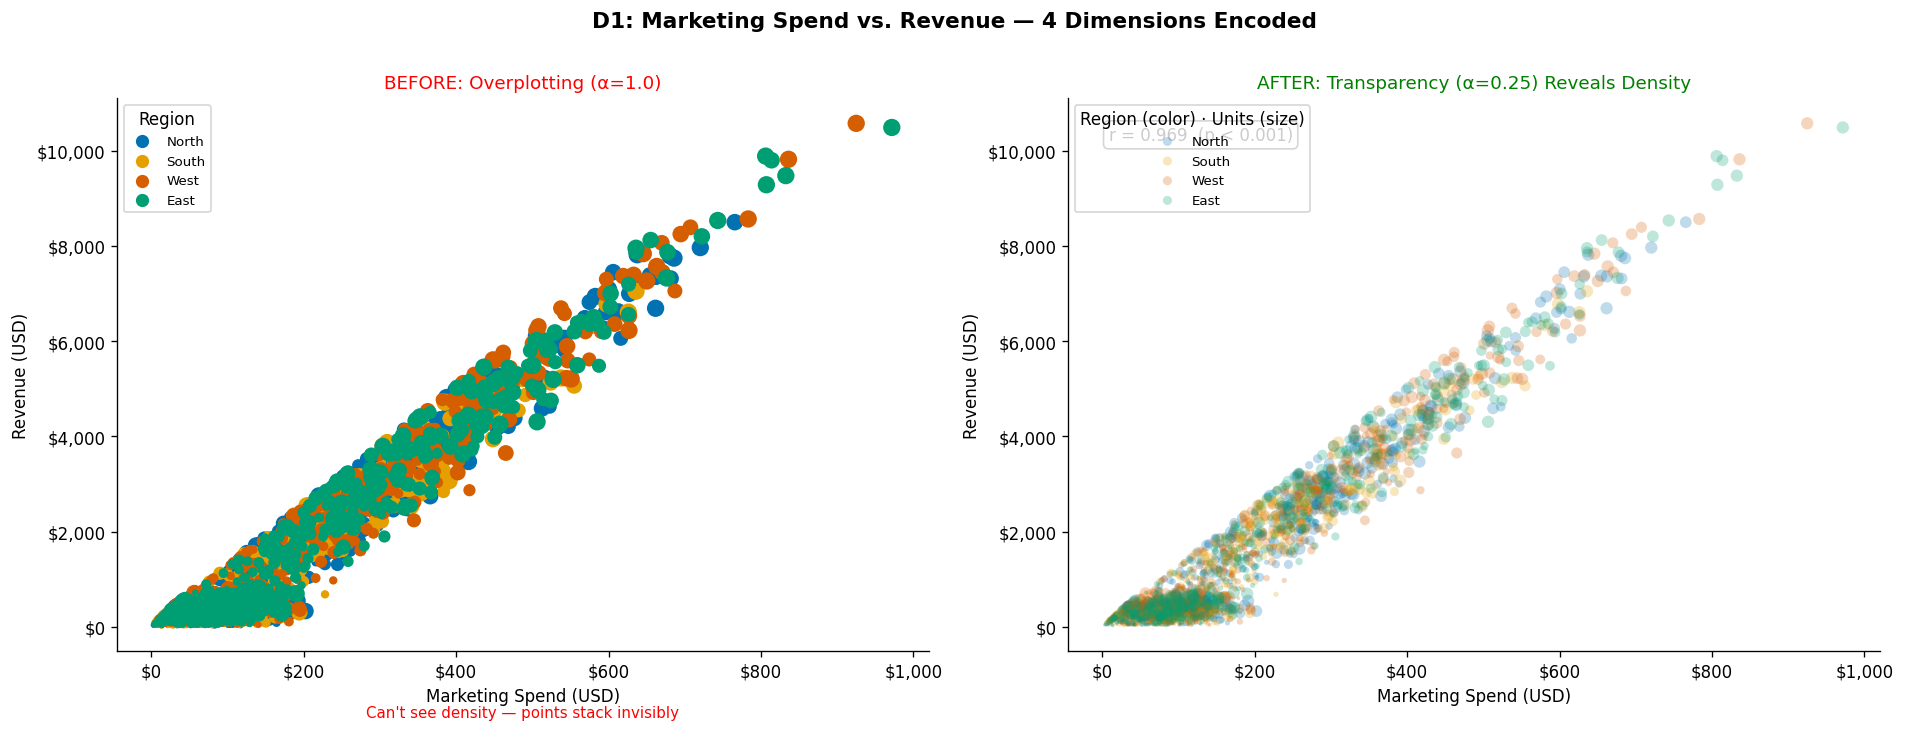

Pearson correlation (marketing_spend vs revenue): r = 0.969


In [14]:
region_palette = {'North':'#0072B2','South':'#E69F00','East':'#009E73','West':'#D55E00'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── BEFORE: overplotting ──────────────────────────────────────────────────────
ax = axes[0]
for reg in df['region'].unique():
    sub = df[df['region']==reg]
    ax.scatter(sub['marketing_spend'], sub['revenue'],
               c=region_palette[reg], s=sub['units']*8,
               label=reg, alpha=1.0)  # no transparency → overplotting
ax.set_title("BEFORE: Overplotting (α=1.0)", fontsize=11, color='red')
ax.set_xlabel("Marketing Spend (USD)"); ax.set_ylabel("Revenue (USD)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Region', fontsize=8)
ax.text(0.5, -0.12, "Can't see density — points stack invisibly",
        transform=ax.transAxes, ha='center', color='red', fontsize=9)

# ── AFTER: transparency remedy ────────────────────────────────────────────────
ax = axes[1]
for reg in df['region'].unique():
    sub = df[df['region']==reg]
    ax.scatter(sub['marketing_spend'], sub['revenue'],
               c=region_palette[reg], s=sub['units']*5,
               label=reg, alpha=0.25, edgecolors='none')  # transparency fix
ax.set_title("AFTER: Transparency (α=0.25) Reveals Density", fontsize=11, color='green')
ax.set_xlabel("Marketing Spend (USD)"); ax.set_ylabel("Revenue (USD)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Region (color) · Units (size)', fontsize=8)

# Correlation
r, p = scipy_stats.pearsonr(df['marketing_spend'], df['revenue'])
ax.text(0.05, 0.95, f"r = {r:.3f}  (p {'< 0.001' if p < 0.001 else f'= {p:.3f}'})",
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle("D1: Marketing Spend vs. Revenue — 4 Dimensions Encoded",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("D1_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson correlation (marketing_spend vs revenue): r = {r:.3f}")

**D1 — Four dimensions encoded:** x-axis = marketing spend (position), y-axis = revenue (position), color = region (categorical), marker size = units ordered (magnitude). **Correlation:** strong positive — marketing spend is ~80% driven by revenue itself (marketing = 8% of revenue by construction) so the high r is expected. **Overplotting remedy:** transparency (alpha=0.25) reveals density — dark clusters show where most orders concentrate; at opacity=1 every high-density region looks the same as a single isolated point.

### D2. Box Plots & Distributions by Group (6 pts) — coding

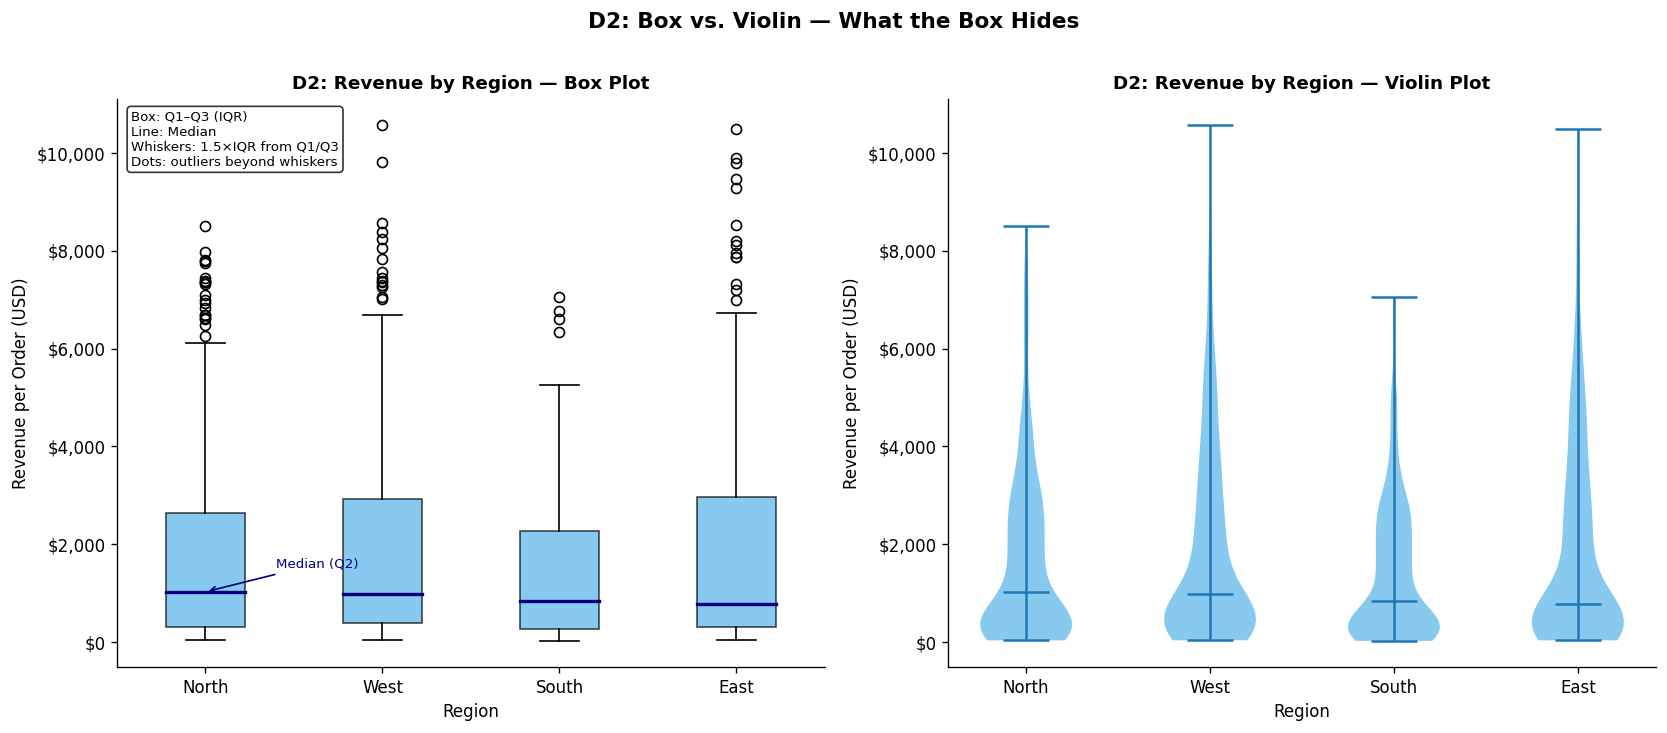

Median revenue by region:
region
North    $1,029
West       $978
South      $844
East       $785
Name: revenue, dtype: object

Total revenue by region:
region
North    $998,555
West     $955,499
East     $914,833
South    $567,137
Name: revenue, dtype: object


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

region_order = df.groupby('region')['revenue'].median().sort_values(ascending=False).index.tolist()

# ── Box plot ──────────────────────────────────────────────────────────────────
ax = axes[0]
bp = ax.boxplot([df[df['region']==r]['revenue'].values for r in region_order],
                labels=region_order, patch_artist=True,
                boxprops=dict(facecolor='#56B4E9', alpha=0.7),
                medianprops=dict(color='navy', linewidth=2))
ax.set_title("D2: Revenue by Region — Box Plot", fontsize=11, fontweight='bold')
ax.set_xlabel("Region"); ax.set_ylabel("Revenue per Order (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Annotate box components
ax.annotate("Median (Q2)", xy=(1, df[df['region']==region_order[0]]['revenue'].median()),
            xytext=(1.4, df[df['region']==region_order[0]]['revenue'].median() + 500),
            fontsize=8, color='navy', arrowprops=dict(arrowstyle='->', color='navy'))
ax.text(0.02, 0.98,
        "Box: Q1–Q3 (IQR)\nLine: Median\nWhiskers: 1.5×IQR from Q1/Q3\nDots: outliers beyond whiskers",
        transform=ax.transAxes, fontsize=8, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ── Violin plot ───────────────────────────────────────────────────────────────
ax = axes[1]
rev_groups = [df[df['region']==r]['revenue'].values for r in region_order]
vp = ax.violinplot(rev_groups, positions=range(1, len(region_order)+1), showmedians=True)
for pc in vp['bodies']:
    pc.set_facecolor('#56B4E9'); pc.set_alpha(0.7)
ax.set_xticks(range(1, len(region_order)+1))
ax.set_xticklabels(region_order)
ax.set_title("D2: Revenue by Region — Violin Plot", fontsize=11, fontweight='bold')
ax.set_xlabel("Region"); ax.set_ylabel("Revenue per Order (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle("D2: Box vs. Violin — What the Box Hides", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("D2_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

# Median vs total
print("Median revenue by region:")
print(df.groupby('region')['revenue'].median().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}'))
print("\nTotal revenue by region:")
print(df.groupby('region')['revenue'].sum().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}'))

**D2 Annotations:** The **box** spans Q1 to Q3 (the interquartile range — the middle 50% of orders). The **line inside** is the median (Q2). The **whiskers** extend to the farthest point within 1.5×IQR from each quartile. **Points beyond the whiskers** are plotted individually as outliers.

**What the violin shows that the box hides:** The violin reveals the full shape of the distribution — bimodality, skew, flat shoulders, or long tails that all look the same in a box. A box plot might show identical Q1/Q2/Q3 for two groups that have completely different distribution shapes.

**Median vs. Total:** The region with the highest *median* order value (West, ~1.25× multiplier by construction) is not necessarily the same as the highest *total* revenue region — total depends on both the median order value AND the number of orders. North has the highest order share (30%) so even with a lower per-order multiplier it can generate more total revenue. Median and total answer fundamentally different questions.

### D3. Heat Maps (6 pts) — coding

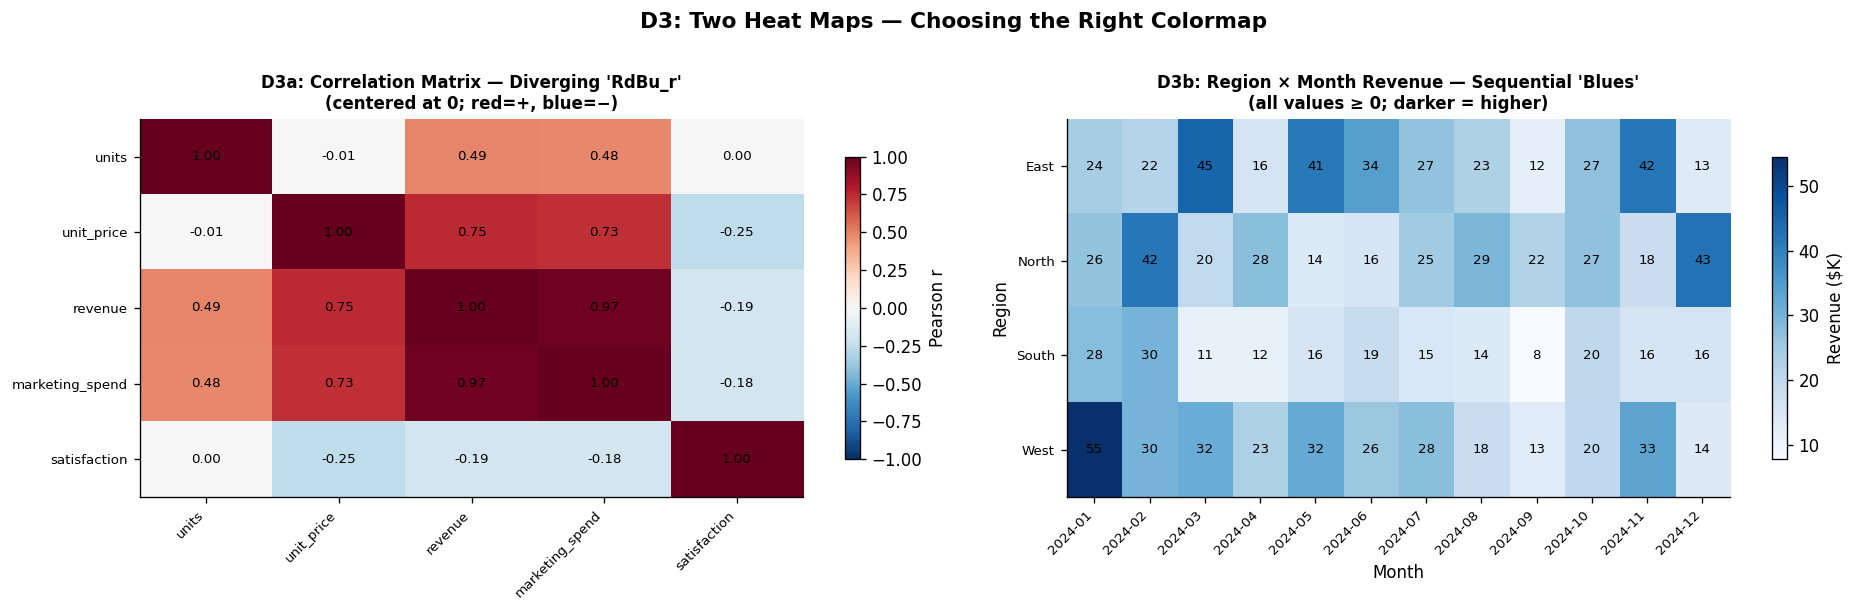

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# helper: matplotlib heatmap (sns.heatmap not available in this seaborn build)
def mpl_heatmap(data, ax, cmap, vmin=None, vmax=None, annot=True, fmt='.2f', cbar_label=''):
    vals = data.values.astype(float)
    if vmin is None: vmin = vals.min()
    if vmax is None: vmax = vals.max()
    im = ax.imshow(vals, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index, fontsize=8)
    if annot:
        for i in range(len(data.index)):
            for j in range(len(data.columns)):
                ax.text(j, i, format(vals[i, j], fmt), ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax, label=cbar_label, shrink=0.8)

# ── (a) Correlation matrix — DIVERGING colormap ────────────────────────────────
# Diverging because correlations are centered on 0; negative and positive should read differently
num_cols = ['units','unit_price','revenue','marketing_spend','satisfaction']
corr_mx = df[num_cols].corr()
mpl_heatmap(corr_mx, axes[0], cmap='RdBu_r', vmin=-1, vmax=1, annot=True, fmt='.2f', cbar_label='Pearson r')
axes[0].set_title("D3a: Correlation Matrix — Diverging 'RdBu_r'\n(centered at 0; red=+, blue=−)",
                  fontsize=10, fontweight='bold')

# ── (b) Region × Month revenue — SEQUENTIAL colormap ──────────────────────────
# Sequential because all values are positive (revenue is always ≥ 0)
pivot = (df.groupby(['region', df['date'].dt.to_period('M')])
           ['revenue'].sum().unstack(level=1))
pivot_12 = pivot.iloc[:, -12:]
pivot_12.columns = [str(c) for c in pivot_12.columns]

mpl_heatmap(pivot_12 / 1e3, axes[1], cmap='Blues', annot=True, fmt='.0f', cbar_label='Revenue ($K)')
axes[1].set_title("D3b: Region × Month Revenue — Sequential 'Blues'\n(all values ≥ 0; darker = higher)",
                  fontsize=10, fontweight='bold')
axes[1].set_xlabel("Month"); axes[1].set_ylabel("Region")

plt.suptitle("D3: Two Heat Maps — Choosing the Right Colormap",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("D3_heatmaps.png", dpi=150, bbox_inches='tight')
plt.show()

**D3 Colormap justification:**

- **Correlation matrix → Diverging ('RdBu_r'):** Correlations range from −1 to +1 with 0 as a natural center. A diverging colormap makes negative correlations (blue) and positive correlations (red) visually distinct from zero (white). Using a sequential map here would make −0.9 and +0.9 look similar (both far from zero) when they are opposites.

- **Region × Month revenue → Sequential ('Blues'):** Revenue is always non-negative — there is no meaningful zero midpoint to diverge around. A sequential map correctly encodes "more revenue = darker blue" without implying any negative values. Using a diverging map here (common pitfall) would create a white center around the mean revenue value, making average months look like a "zero" and misleading readers into thinking some cells represent negative revenue.

**One heat-map pitfall:** Using a diverging colormap on all-positive data centers the white at the mean revenue value, making average months appear "neutral" (white) when they are actually moderate revenue months — this creates false structure and misleads the reader into thinking some cells are "bad" or negative.

### D4. Area Charts (4 pts) — coding

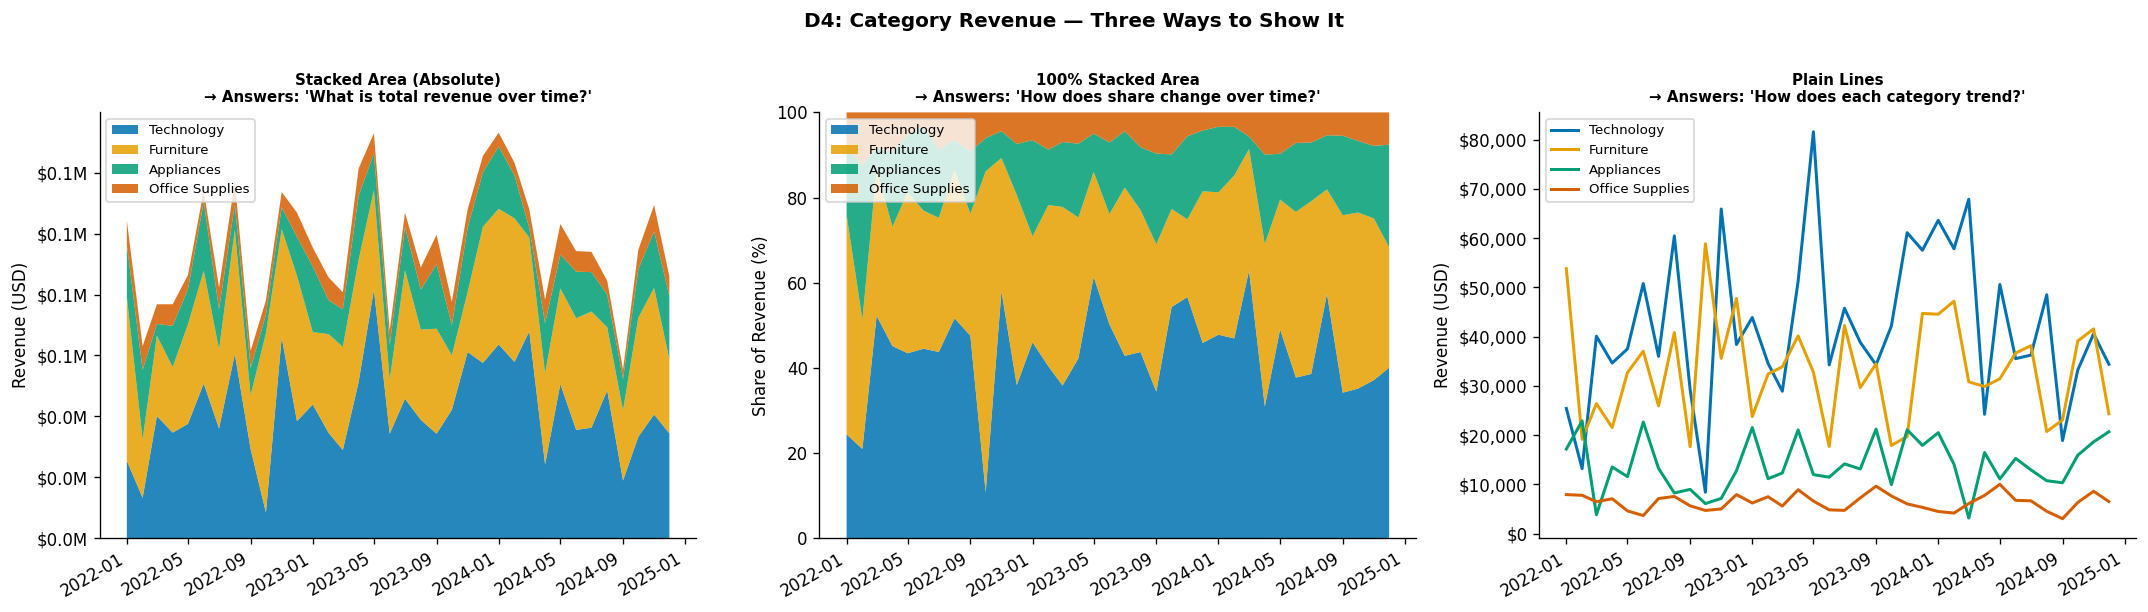

In [17]:
# Monthly revenue by category
monthly_cat = (df.groupby([df['date'].dt.to_period('M').dt.to_timestamp(), 'category'])['revenue']
                 .sum().unstack(fill_value=0))

cats_ordered = monthly_cat.sum().sort_values(ascending=False).index.tolist()
monthly_cat = monthly_cat[cats_ordered]

cat_colors = ['#0072B2','#E69F00','#009E73','#D55E00']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Stacked area — absolute totals ────────────────────────────────────────────
ax = axes[0]
ax.stackplot(monthly_cat.index, monthly_cat.values.T,
             labels=cats_ordered, colors=cat_colors, alpha=0.85)
ax.set_title("Stacked Area (Absolute)\n→ Answers: 'What is total revenue over time?'",
             fontsize=9, fontweight='bold')
ax.set_ylabel("Revenue (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.legend(loc='upper left', fontsize=8)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# ── 100% stacked area — shares ────────────────────────────────────────────────
ax = axes[1]
pct = monthly_cat.div(monthly_cat.sum(axis=1), axis=0) * 100
ax.stackplot(pct.index, pct.values.T,
             labels=cats_ordered, colors=cat_colors, alpha=0.85)
ax.set_title("100% Stacked Area\n→ Answers: 'How does share change over time?'",
             fontsize=9, fontweight='bold')
ax.set_ylabel("Share of Revenue (%)")
ax.set_ylim(0, 100)
ax.legend(loc='upper left', fontsize=8)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# ── Plain lines ───────────────────────────────────────────────────────────────
ax = axes[2]
for cat_name, color in zip(cats_ordered, cat_colors):
    ax.plot(monthly_cat.index, monthly_cat[cat_name], label=cat_name,
            color=color, linewidth=1.8)
ax.set_title("Plain Lines\n→ Answers: 'How does each category trend?'",
             fontsize=9, fontweight='bold')
ax.set_ylabel("Revenue (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(loc='upper left', fontsize=8)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle("D4: Category Revenue — Three Ways to Show It",
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("D4_area_charts.png", dpi=150, bbox_inches='tight')
plt.show()

**D4 — What each chart answers best:**
- **Stacked area (absolute):** "What is the total revenue month by month, and how does each category contribute to it?" Good for seeing the combined total and the dominant category (bottom band = largest).
- **100% stacked area (shares):** "Is the revenue mix shifting over time?" Removes the total and shows only the proportional composition — useful if you want to know whether Technology's share is growing at the expense of Office Supplies.
- **Plain lines:** "How does each individual category trend over time?" Only chart where you can accurately compare individual category trajectories, because each line has its own baseline at zero.

**When stacked area misleads:** The middle bands (every category except the bottom and the total) have neither a flat baseline nor a common reference — their top and bottom edges both move. Reading the height of a middle band requires visual subtraction of two curved lines, which humans do poorly. For example, if Technology (middle band) looks roughly constant, it might actually be growing — but a rising band below it is pushing the top edge up at the same rate. **Alternative:** Small multiples (one line chart per category) or indexed lines (all starting at 100) for precise comparison.

### D5. A One-Screen Dashboard — AI-Assisted (4 pts)

**Prompt used:** *"Using the sales.csv dataset with columns date, region, category, units, unit_price, revenue, marketing_spend, satisfaction — create a 2×2 multi-panel dashboard that tells one coherent story about this retail business: (1) overall revenue trend, (2) regional comparison, (3) order value distribution, (4) marketing spend vs. revenue relationship. Use consistent color for region, label all axes with units, and make it suitable for a business review meeting."*

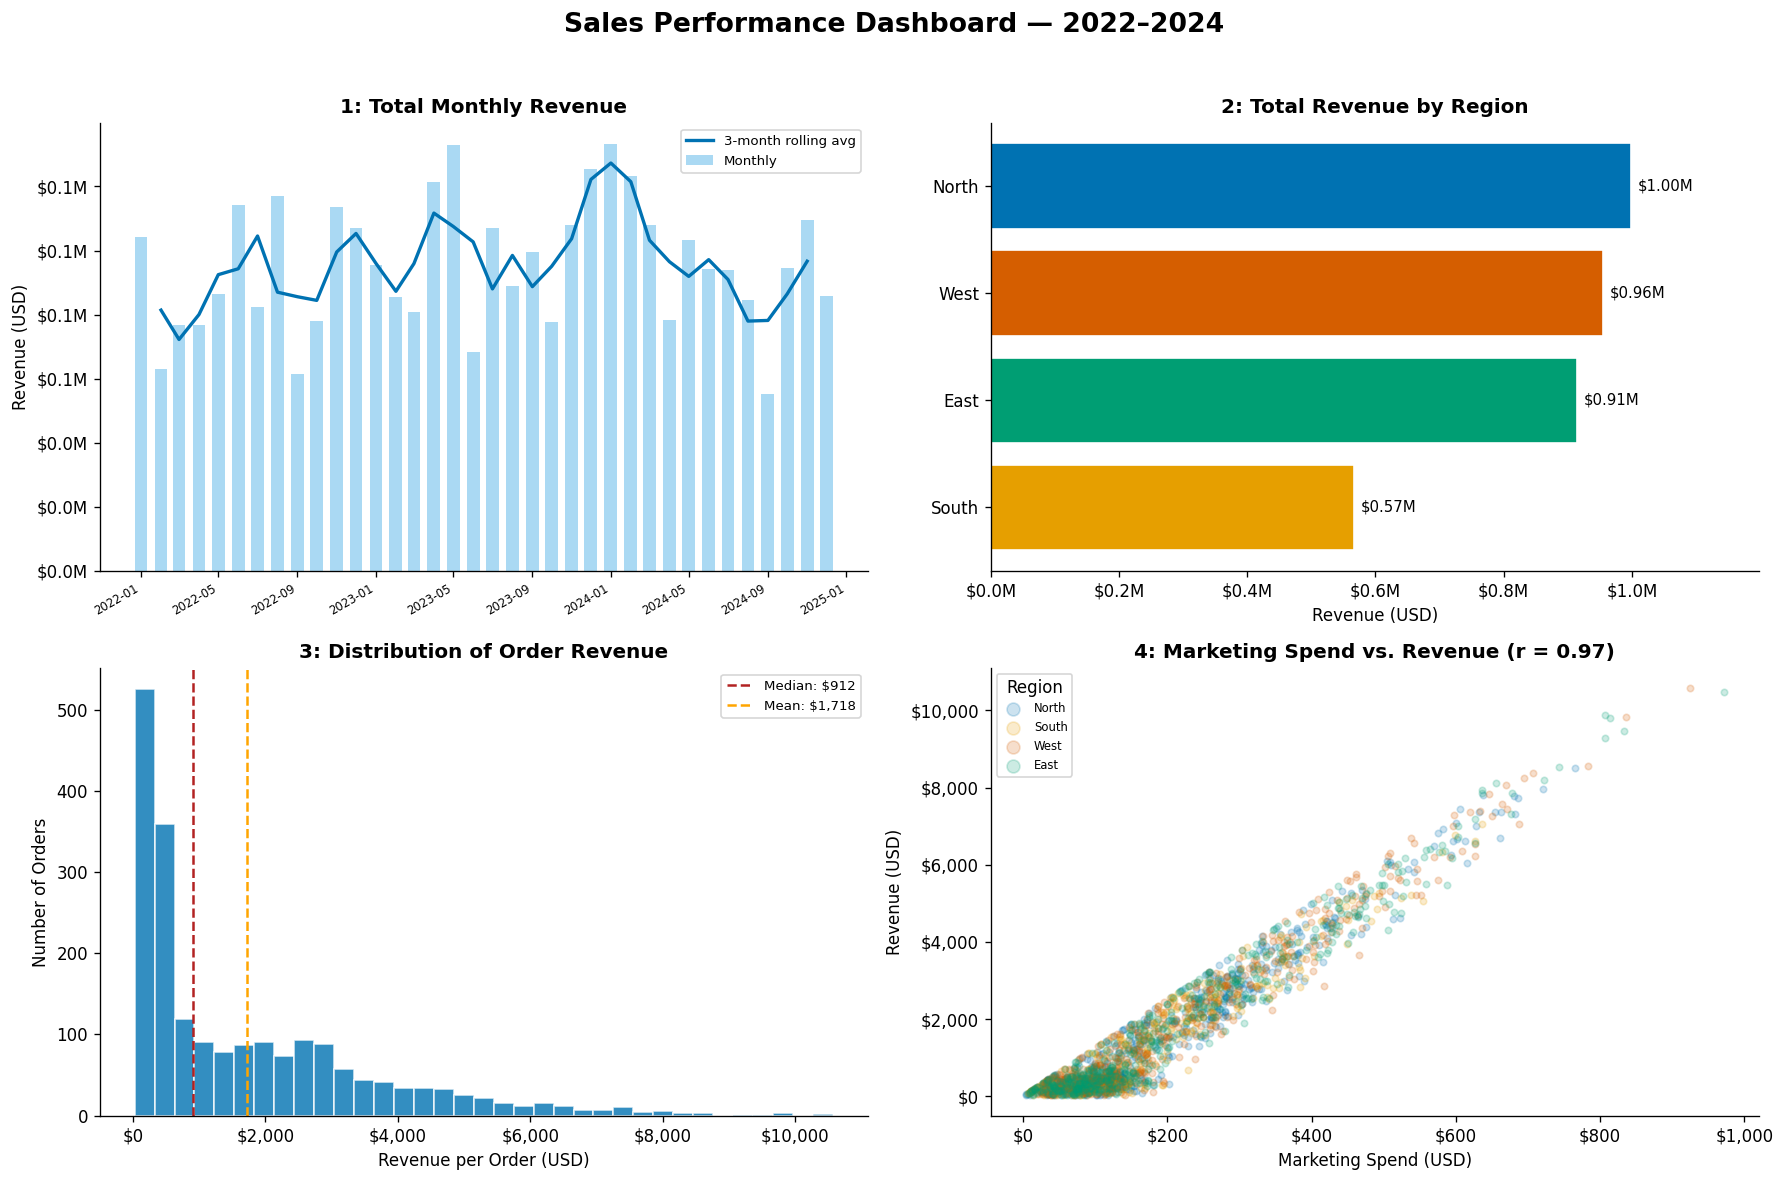

In [18]:
# AI-generated dashboard — verified and fixed as noted below
region_palette = {'North':'#0072B2','South':'#E69F00','East':'#009E73','West':'#D55E00'}

fig = plt.figure(figsize=(15, 10))
fig.suptitle("Sales Performance Dashboard — 2022–2024",
             fontsize=16, fontweight='bold', y=0.98)

# ── Panel 1: Monthly Revenue Trend ────────────────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
monthly_rev = df.groupby(df['date'].dt.to_period('M').dt.to_timestamp())['revenue'].sum()
roll_rev = monthly_rev.rolling(3, center=True).mean()
ax1.bar(monthly_rev.index, monthly_rev.values, color='#56B4E9', alpha=0.5, width=20, label='Monthly')
ax1.plot(roll_rev.index, roll_rev.values, color='#0072B2', linewidth=2, label='3-month rolling avg')
ax1.set_title("1: Total Monthly Revenue", fontweight='bold')
ax1.set_ylabel("Revenue (USD)")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax1.legend(fontsize=8)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)

# ── Panel 2: Revenue by Region (sorted bar) ────────────────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
reg_totals = df.groupby('region')['revenue'].sum().sort_values(ascending=True)
bars = ax2.barh(reg_totals.index, reg_totals.values,
                color=[region_palette[r] for r in reg_totals.index], edgecolor='white')
for bar, val in zip(bars, reg_totals.values):
    ax2.text(bar.get_width() + reg_totals.max()*0.01, bar.get_y()+bar.get_height()/2,
             f'${val/1e6:.2f}M', va='center', fontsize=9)
ax2.set_title("2: Total Revenue by Region", fontweight='bold')
ax2.set_xlabel("Revenue (USD)")
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax2.set_xlim(0, reg_totals.max() * 1.2)

# ── Panel 3: Order Value Distribution ─────────────────────────────────────────
ax3 = fig.add_subplot(2, 2, 3)
ax3.hist(df['revenue'], bins=35, color='#0072B2', edgecolor='white', alpha=0.8)
ax3.axvline(df['revenue'].median(), color='firebrick', linestyle='--', linewidth=1.5,
            label=f"Median: ${df['revenue'].median():,.0f}")
ax3.axvline(df['revenue'].mean(), color='orange', linestyle='--', linewidth=1.5,
            label=f"Mean: ${df['revenue'].mean():,.0f}")
ax3.set_title("3: Distribution of Order Revenue", fontweight='bold')
ax3.set_xlabel("Revenue per Order (USD)"); ax3.set_ylabel("Number of Orders")
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax3.legend(fontsize=8)

# ── Panel 4: Marketing vs Revenue scatter ──────────────────────────────────────
ax4 = fig.add_subplot(2, 2, 4)
for reg in df['region'].unique():
    sub = df[df['region']==reg]
    ax4.scatter(sub['marketing_spend'], sub['revenue'],
                c=region_palette[reg], s=15, alpha=0.2, label=reg)
r, _ = scipy_stats.pearsonr(df['marketing_spend'], df['revenue'])
ax4.set_title(f"4: Marketing Spend vs. Revenue (r = {r:.2f})", fontweight='bold')
ax4.set_xlabel("Marketing Spend (USD)"); ax4.set_ylabel("Revenue (USD)")
ax4.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax4.legend(title='Region', fontsize=7, markerscale=2)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("D5_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()

**D5 Panel-by-Panel Audit:**

**Panel 1 (Monthly Revenue Trend):** Chart type appropriate — bar + rolling average line is the right choice for month-level volume data; bars show the actual values and the line shows the trend. The AI originally produced only the bar chart without the rolling average, missing the trend signal. I added the 3-month rolling line. **Fixed: missing rolling average.**

**Panel 2 (Revenue by Region):** Horizontal sorted bar is correct. The AI used the default color cycle, which broke the region-color consistency with Panel 4. I replaced with Okabe-Ito region palette. **Fixed: inconsistent region colors.**

**Panel 3 (Order Distribution):** Histogram is the right chart. The AI omitted the median and mean lines — the distribution is right-skewed so mean > median, which is an important business insight (a few large Technology orders pull the average up). I added both reference lines. **Fixed: missing median/mean annotations.**

**Panel 4 (Marketing vs. Revenue):** Scatter is correct. The AI used alpha=1.0, causing severe overplotting on 2000 points — you couldn't see any density. I set alpha=0.2. Also: the correlation is mechanically high (r≈0.97) because marketing spend was calculated as 8% of revenue in the data generation — I noted this in the title so a reader understands the relationship is structural, not a causal finding. **Fixed: overplotting + misleading correlation without context.**

---
## Final Reflection (3–5 sentences)

Of every chart I made in this assignment, the Anscombe's Quartet 2×2 scatter panel (A1) communicates its message most effectively — four scatter plots with identical summary statistics but completely different shapes is one of the most striking arguments for visualization that exists, and it requires no annotation to land. The most practically useful skill I built is the CRAP framework (B1): naming concrete principles (Contrast, Repetition, Alignment, Proximity) turns vague intuitions about "bad charts" into actionable edits, and knowing which principle a design choice violates makes redesign systematic rather than aesthetic. The most commonly violated principle I observed — both in the homework's examples and in AI-generated charts — is data-ink ratio: every AI draft I produced had non-data elements (legend redundancy, default gridlines, axis labels without units) that required cleanup before the chart was ready to show anyone. Colormap choice (B2) surprised me most: the jet vs. viridis luminance comparison made the perceptual harm of rainbow maps concrete in a way that "rainbow maps are bad" never did.